# Install Libraries

In [1]:
%pip install --upgrade numpy pandas pyarrow scipy scikit-learn matplotlib seaborn statsmodels joblib

Note: you may need to restart the kernel to use updated packages.


## 2. Import libraries

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

import statsmodels.api as sm
import joblib

# Display and plotting settings
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

# 3. Understand the datasets

In [3]:
df_asset = pd.read_parquet('asset_returns.parquet')
df_alphas = pd.read_parquet('alphas_panel.parquet')

 We inspect the shape, columns, data types, missing values, and sample rows : 

In [4]:
for name, df in {"Alphas": df_alphas, "Returns": df_asset}.items():
    print(f"\n{'=' * 60}\n{name}")
    print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
    print(f"Index names: {df.index.names}")
    print(f"Columns: {df.columns.tolist()}")

    display(df.head())
    df.info()


Alphas
Rows: 1,260,000 | Columns: 50
Index names: ['date', 'asset']
Columns: ['alpha_00', 'alpha_01', 'alpha_02', 'alpha_03', 'alpha_04', 'alpha_05', 'alpha_06', 'alpha_07', 'alpha_08', 'alpha_09', 'alpha_10', 'alpha_11', 'alpha_12', 'alpha_13', 'alpha_14', 'alpha_15', 'alpha_16', 'alpha_17', 'alpha_18', 'alpha_19', 'alpha_20', 'alpha_21', 'alpha_22', 'alpha_23', 'alpha_24', 'alpha_25', 'alpha_26', 'alpha_27', 'alpha_28', 'alpha_29', 'alpha_30', 'alpha_31', 'alpha_32', 'alpha_33', 'alpha_34', 'alpha_35', 'alpha_36', 'alpha_37', 'alpha_38', 'alpha_39', 'alpha_40', 'alpha_41', 'alpha_42', 'alpha_43', 'alpha_44', 'alpha_45', 'alpha_46', 'alpha_47', 'alpha_48', 'alpha_49']


alpha_00  alpha_01  alpha_02  alpha_03  alpha_04  alpha_05  \
date       asset                                                               
2012-01-02 A000  -0.647321  0.396382  0.557543  0.142403  0.692849  0.060497   
           A001   0.053436 -0.427372 -0.479474 -1.612863  0.839227 -0.802641   
           A002  -0.247054 -0.368746 -0.682325  0.559806 -0.724621  1.067247   
           A003  -0.024872 -1.137579 -1.102422  1.047860  0.338492  1.339472   
           A004  -0.096782  1.193079  1.187382  0.930683  2.105840 -0.367970   

                  alpha_06  alpha_07  alpha_08  alpha_09  alpha_10  alpha_11  \
date       asset                                                               
2012-01-02 A000   0.545765  1.777168  2.072413  0.077311  0.848755  1.047112   
           A001  -1.164435 -0.552582 -0.217185  1.322768 -0.577364 -1.736714   
           A002   1.477000 -0.828798  1.437544 -0.657861 -0.405037 -0.169128   
           A003  -0.668233  0.731119 -0.455154 -1.454676  1.473804 -0.566226   
           A004  -0.588188  1.380839  1.231621 -0.125086 -0.662490  1.448777   

                  alpha_12  alpha_13  alpha_14  alpha_15  alpha_16  alpha_17  \
date       asset                                                               
2012-01-02 A000   0.110500 -0.857234 -0.017357 -0.562407  0.478063  1.181259   
           A001  -0.506708  0.247626  0.643248  2.752681  1.439288 -0.492243   
           A002  -0.408229  0.640932  0.765793  0.309459  0.826918 -0.954990   
           A003   1.215142 -0.629985 -0.681528 -0.735652  0.709536  0.801510   
           A004  -1.241442 -0.595378  0.036049  1.935203  1.845297  1.177893   

                  alpha_18  alpha_19  alpha_20  alpha_21  alpha_22  alpha_23  \
date       asset                                                               
2012-01-02 A000  -0.922365 -0.147299 -0.747661  0.742935  1.060047  0.077144   
           A001  -0.015003 -0.299213  0.342848 -0.651815 -2.272225  0.048291   
           A002   0.029654  0.115271  0.632416  0.098952  1.353895 -0.965790   
           A003   0.308793  0.077812 -0.397040  0.404565  0.662485  0.887509   
           A004  -2.514295 -1.139710  0.058009  0.629526  0.806754  0.323814   

                  alpha_24  alpha_25  alpha_26  alpha_27  alpha_28  alpha_29  \
date       asset                                                               
2012-01-02 A000  -0.565996 -0.702275  0.747308 -0.933645  0.458692  0.075866   
           A001  -0.542922  0.244566 -0.023477 -0.391184  0.403829 -1.988745   
           A002  -0.649995  0.579515 -0.600522  0.560094  0.456306  2.187017   
           A003   0.477188 -0.208138  0.168869  0.724677  0.803194  1.493412   
           A004   1.200338  0.075000 -1.636647 -1.390916 -1.067130  1.473822   

                  alpha_30  alpha_31  alpha_32  alpha_33  alpha_34  alpha_35  \
date       asset                                                               
2012-01-02 A000   0.900324  0.306963  1.593816 -0.967502  0.911976  2.010059   
           A001   1.710141  0.595953  0.818525 -1.394213 -3.181346  0.425837   
           A002   0.595066  0.137632  0.613752 -1.061182  2.051508 -1.505440   
           A003  -1.277565  0.160314 -2.532732  1.934526  1.956323 -0.161488   
           A004   1.567457  0.793004  2.414661  0.313380 -0.578366 -1.329074   

                  alpha_36  alpha_37  alpha_38  alpha_39  alpha_40  alpha_41  \
date       asset                                                               
2012-01-02 A000   0.338786 -0.425357  1.447951 -0.823186  2.130442  1.189914   
           A001  -1.211613 -1.805099 -3.025008 -0.846255  0.416780 -0.936805   
           A002   0.150438 -0.346173  0.335716 -0.190606  0.333353  0.378896   
           A003   2.064594  1.472612  0.100662 -1.656146 -2.906037  0.667876   
           A004  -0.401048  0.551596  0.501516  0.786166  0.823446  1.027737   

                  alpha_42  alpha_43  alpha_44  alpha_45  alpha_46  alpha_47  \
date       

<class 'pandas.DataFrame'>
MultiIndex: 1260000 entries, (Timestamp('2012-01-02 00:00:00'), 'A000') to (Timestamp('2021-08-27 00:00:00'), 'A499')
Data columns (total 50 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   alpha_00  1260000 non-null  float64
 1   alpha_01  1260000 non-null  float64
 2   alpha_02  1260000 non-null  float64
 3   alpha_03  1260000 non-null  float64
 4   alpha_04  1260000 non-null  float64
 5   alpha_05  1260000 non-null  float64
 6   alpha_06  1260000 non-null  float64
 7   alpha_07  1260000 non-null  float64
 8   alpha_08  1260000 non-null  float64
 9   alpha_09  1260000 non-null  float64
 10  alpha_10  1260000 non-null  float64
 11  alpha_11  1260000 non-null  float64
 12  alpha_12  1260000 non-null  float64
 13  alpha_13  1260000 non-null  float64
 14  alpha_14  1260000 non-null  float64
 15  alpha_15  1260000 non-null  float64
 16  alpha_16  1260000 non-null  float64
 17  alpha_17  1260000 non-null  float64
 1

,A000,A001,A002,A003,A004,A005,A006,A007,A008,A009,A010,A011,A012,A013,A014,A015,A016,A017,A018,A019,A020,A021,A022,A023,A024,A025,A026,A027,A028,A029,...,A470,A471,A472,A473,A474,A475,A476,A477,A478,A479,A480,A481,A482,A483,A484,A485,A486,A487,A488,A489,A490,A491,A492,A493,A494,A495,A496,A497,A498,A499
2012-01-02,-0.015140,0.022112,0.004056,-0.020686,-0.024156,-0.003203,0.022055,-0.004447,0.018718,0.003723,0.005204,-0.021646,0.012599,-0.006389,0.011893,-0.013587,0.000720,0.003925,-0.003341,0.004871,-0.005486,-0.010984,0.022473,0.014109,-0.013193,0.006522,-0.012965,-0.018782,0.014483,-0.026935,...,0.007016,-0.011569,0.013347,-0.005546,-0.011052,-0.020455,0.002496,0.011466,0.002427,0.032679,0.019974,-0.006713,-0.006099,0.005452,-0.014205,0.016526,0.003804,0.003029,0.009163,0.023984,0.001009,-0.002972,0.021038,0.013134,-0.006225,-0.001604,0.001832,0.004005,-0.021622,-0.023874
2012-01-03,-0.008715,-0.009609,-0.003745,0.012390,0.001087,0.008186,-0.013666,-0.001250,0.011866,0.014286,-0.004439,0.007976,0.038028,0.004440,-0.006768,0.002132,0.008056,0.002403,0.003080,-0.017524,-0.009304,0.002061,0.003069,-0.002890,0.003480,0.007827,0.019631,0.001998,0.009517,-0.003391,...,0.011789,-0.015813,-0.000877,-0.025874,0.008113,-0.001796,-0.017831,0.023048,-0.013848,0.015068,-0.005438,0.031261,0.015823,-0.009627,-0.008120,0.012420,0.001650,0.000278,0.023018,-0.004824,0.006731,0.018720,0.017629,0.002362,0.000528,-0.020285,-0.012057,0.009677,0.002321,0.003663
2012-01-04,0.012316,-0.021273,-0.007753,0.000787,-0.013141,0.017741,0.010283,0.000311,0.024737,-0.026302,-0.004695,0.001542,-0.017311,0.001161,-0.019184,0.006984,0.011115,0.000759,-0.030320,-0.017442,0.004814,-0.002745,-0.044361,0.014652,-0.002319,-0.017208,0.010445,-0.012646,-0.012841,0.002005,...,0.001491,0.012756,-0.009636,0.007144,-0.002464,-0.017455,-0.007066,-0.009309,-0.014557,0.004210,-0.000097,-0.029014,-0.028034,0.002458,-0.016243,0.002154,0.007736,-0.021071,-0.023975,0.020554,0.001455,-0.009423,-0.017920,-0.011044,-0.021321,0.009122,-0.014348,0.012912,-0.009135,-0.017459
2012-01-05,-0.010491,-0.043697,-0.007081,-0.005110,0.009143,-0.032965,0.013240,0.007251,0.016056,-0.005570,0.009478,-0.027016,0.006199,-0.015760,-0.028007,-0.021086,-0.005865,-0.016527,0.002477,-0.030803,-0.036483,0.016753,0.008612,-0.020733,-0.005513,0.009132,0.000681,-0.000884,0.013281,-0.015179,...,0.005574,0.001024,-0.014627,0.003135,0.006832,-0.016615,-0.011397,-0.039410,-0.021500,-0.013912,-0.003414,-0.020632,-0.011784,-0.023277,-0.002457,0.003411,0.001057,-0.002326,-0.026623,-0.015009,-0.010889,-0.009972,-0.003770,0.017144,0.007848,-0.019980,0.006801,0.005235,-0.016004,0.010470
2012-01-06,0.006275,-0.011965,0.017995,0.008675,0.003425,0.009335,-0.001912,0.019869,0.005122,0.012625,0.017501,-0.006835,-0.003885,-0.024264,0.015328,-0.009233,0.014594,0.014386,0.015741,-0.010263,0.008722,0.033177,0.036195,0.025393,0.016650,-0.002022,0.022660,0.004214,0.015076,-0.000553,...,-0.001391,-0.013015,0.015260,0.036312,0.011560,-0.009961,0.011856,0.011976,0.023854,0.014982,-0.035196,0.021850,-0.006402,-0.010949,0.007819,0.012468,-0.014062,0.015891,0.018881,0.012805,-0.002887,-0.006378,0.025762,-0.013685,0.025150,0.008473,0.005714,-0.016363,0.006090,0.014000


<class 'pandas.DataFrame'>
DatetimeIndex: 2520 entries, 2012-01-02 to 2021-08-27
Columns: 500 entries, A000 to A499
dtypes: float64(500)
memory usage: 9.6 MB


In [5]:
for name, df in {"Alphas": df_alphas, "Returns": df_asset}.items():
    print(f"\n{name}: missing values")

    missing = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
    })
    display(missing.sort_values("missing_pct", ascending=False))

    print(f"{name}: numerical summary")
    display(df.describe().T)


Alphas: missing values


,dtype,missing_count,missing_pct
alpha_00,float64,0,0.0
alpha_01,float64,0,0.0
alpha_02,float64,0,0.0
alpha_03,float64,0,0.0
alpha_04,float64,0,0.0
alpha_05,float64,0,0.0
alpha_06,float64,0,0.0
alpha_07,float64,0,0.0
alpha_08,float64,0,0.0
alpha_09,float64,0,0.0


Alphas: numerical summary


,count,mean,std,min,25%,50%,75%,max
alpha_00,1260000.0,-2.770271e-19,1.0,-4.498709,-0.676569,0.000657,0.676501,4.840527
alpha_01,1260000.0,-4.603020e-19,1.0,-5.200718,-0.675477,0.000553,0.675874,4.844199
alpha_02,1260000.0,1.466199e-19,1.0,-5.575684,-0.674487,0.000640,0.675732,4.712660
alpha_03,1260000.0,1.621278e-19,1.0,-4.838597,-0.673898,0.002119,0.676449,5.096474
alpha_04,1260000.0,1.712916e-19,1.0,-4.715448,-0.673476,0.002442,0.674738,4.509379
alpha_05,1260000.0,-3.764185e-19,1.0,-4.769758,-0.674404,-0.003837,0.670266,4.411661
alpha_06,1260000.0,5.159894e-19,1.0,-4.323447,-0.718478,0.000544,0.718288,3.907338
alpha_07,1260000.0,8.035900e-20,1.0,-4.353808,-0.677825,-0.000444,0.675070,4.644055
alpha_08,1260000.0,-6.217249e-19,1.0,-4.707587,-0.678565,-0.000538,0.677310,4.845204
alpha_09,1260000.0,-3.305997e-19,1.0,-4.019739,-0.734176,0.001612,0.733822,3.955482



Returns: missing values


,dtype,missing_count,missing_pct
A000,float64,0,0.0
A001,float64,0,0.0
A002,float64,0,0.0
A003,float64,0,0.0
A004,float64,0,0.0
...,...,...,...
A495,float64,0,0.0
A496,float64,0,0.0
A497,float64,0,0.0
A498,float64,0,0.0


Returns: numerical summary


,count,mean,std,min,25%,50%,75%,max
A000,2520.0,0.000371,0.015426,-0.056332,-0.009884,0.000860,0.010635,0.061427
A001,2520.0,0.000220,0.015748,-0.057993,-0.010362,0.000262,0.011220,0.056788
A002,2520.0,0.000701,0.015963,-0.057654,-0.010399,0.000886,0.011089,0.059022
A003,2520.0,0.000460,0.015092,-0.060444,-0.009264,0.000146,0.010651,0.054264
A004,2520.0,-0.000019,0.015194,-0.053126,-0.010312,-0.000176,0.009992,0.054210
...,...,...,...,...,...,...,...,...
A495,2520.0,0.000447,0.015964,-0.047860,-0.010700,0.000612,0.011040,0.050943
A496,2520.0,-0.000100,0.015455,-0.055627,-0.011054,-0.000088,0.010404,0.058200
A497,2520.0,-0.000058,0.015725,-0.058198,-0.010443,-0.000084,0.010436,0.056997
A498,2520.0,0.000621,0.015300,-0.049106,-0.009753,0.000043,0.011210,0.061904


### 3.1 Correlation between stocks

We compare stock return histories to identify equities that move together.

In [6]:
stock_corr = df_asset.corr(method="pearson", min_periods=252)

print(f"Correlation matrix: {stock_corr.shape}")
display(stock_corr.iloc[:5, :5])

Correlation matrix: (500, 500)


,A000,A001,A002,A003,A004
A000,1.000000,0.076701,0.084375,0.050473,0.063566
A001,0.076701,1.000000,0.131986,0.070536,0.061909
A002,0.084375,0.131986,1.000000,0.044162,0.095766
A003,0.050473,0.070536,0.044162,1.000000,0.053727
A004,0.063566,0.061909,0.095766,0.053727,1.000000


count    124750.000000
mean          0.087103
std           0.037787
min          -0.054387
25%           0.060417
50%           0.085611
75%           0.112375
max           0.280855
Name: correlation, dtype: float64

Most positively correlated pairs:


,stock_1,stock_2,correlation
0,A117,A280,0.280855
1,A280,A428,0.269677
2,A038,A280,0.269243
3,A132,A280,0.265085
4,A132,A400,0.256477
5,A280,A318,0.254783
6,A038,A428,0.254519
7,A280,A395,0.254069
8,A117,A481,0.246541
9,A038,A481,0.245579


Lowest-correlation pairs:


,stock_1,stock_2,correlation
0,A172,A369,-0.054387
1,A367,A434,-0.045570
2,A151,A162,-0.040572
3,A326,A386,-0.037675
4,A253,A309,-0.034501
5,A251,A450,-0.034007
6,A253,A406,-0.033483
7,A215,A443,-0.033357
8,A131,A242,-0.032927
9,A166,A446,-0.032458


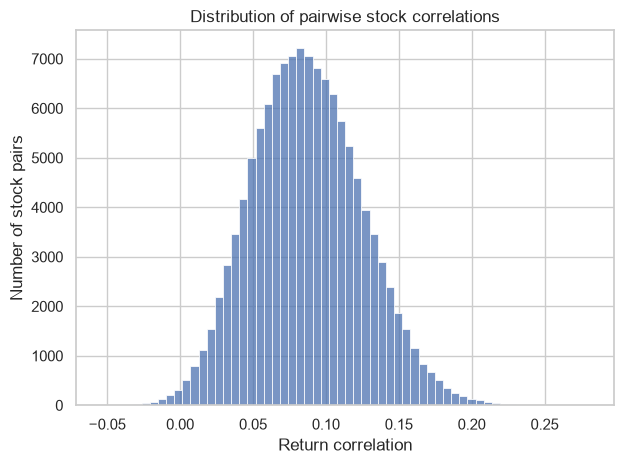

In [7]:
upper_triangle = np.triu(
    np.ones(stock_corr.shape, dtype=bool), k=1
)

pair_corr = stock_corr.where(upper_triangle).stack()
pair_corr.index.names = ["stock_1", "stock_2"]
pair_corr.name = "correlation"

display(pair_corr.describe())

print("Most positively correlated pairs:")
display(pair_corr.nlargest(10).reset_index())

print("Lowest-correlation pairs:")
display(pair_corr.nsmallest(10).reset_index())

sns.histplot(pair_corr, bins=60)
plt.title("Distribution of pairwise stock correlations")
plt.xlabel("Return correlation")
plt.ylabel("Number of stock pairs")
plt.tight_layout()
plt.show()

Stock return correlations are generally weak and positive, with an average of 0.087. Even the most correlated pair has a correlation of only 0.281, while the lowest correlations are slightly negative.

This suggests potential diversification benefits across the universe. However, full-period correlations can hide changes over time and do not establish whether our alpha signals predict returns.

### 3.2 Correlation between alpha signals

We examine correlations between the 50 alpha signals to identify similar or opposing signals.

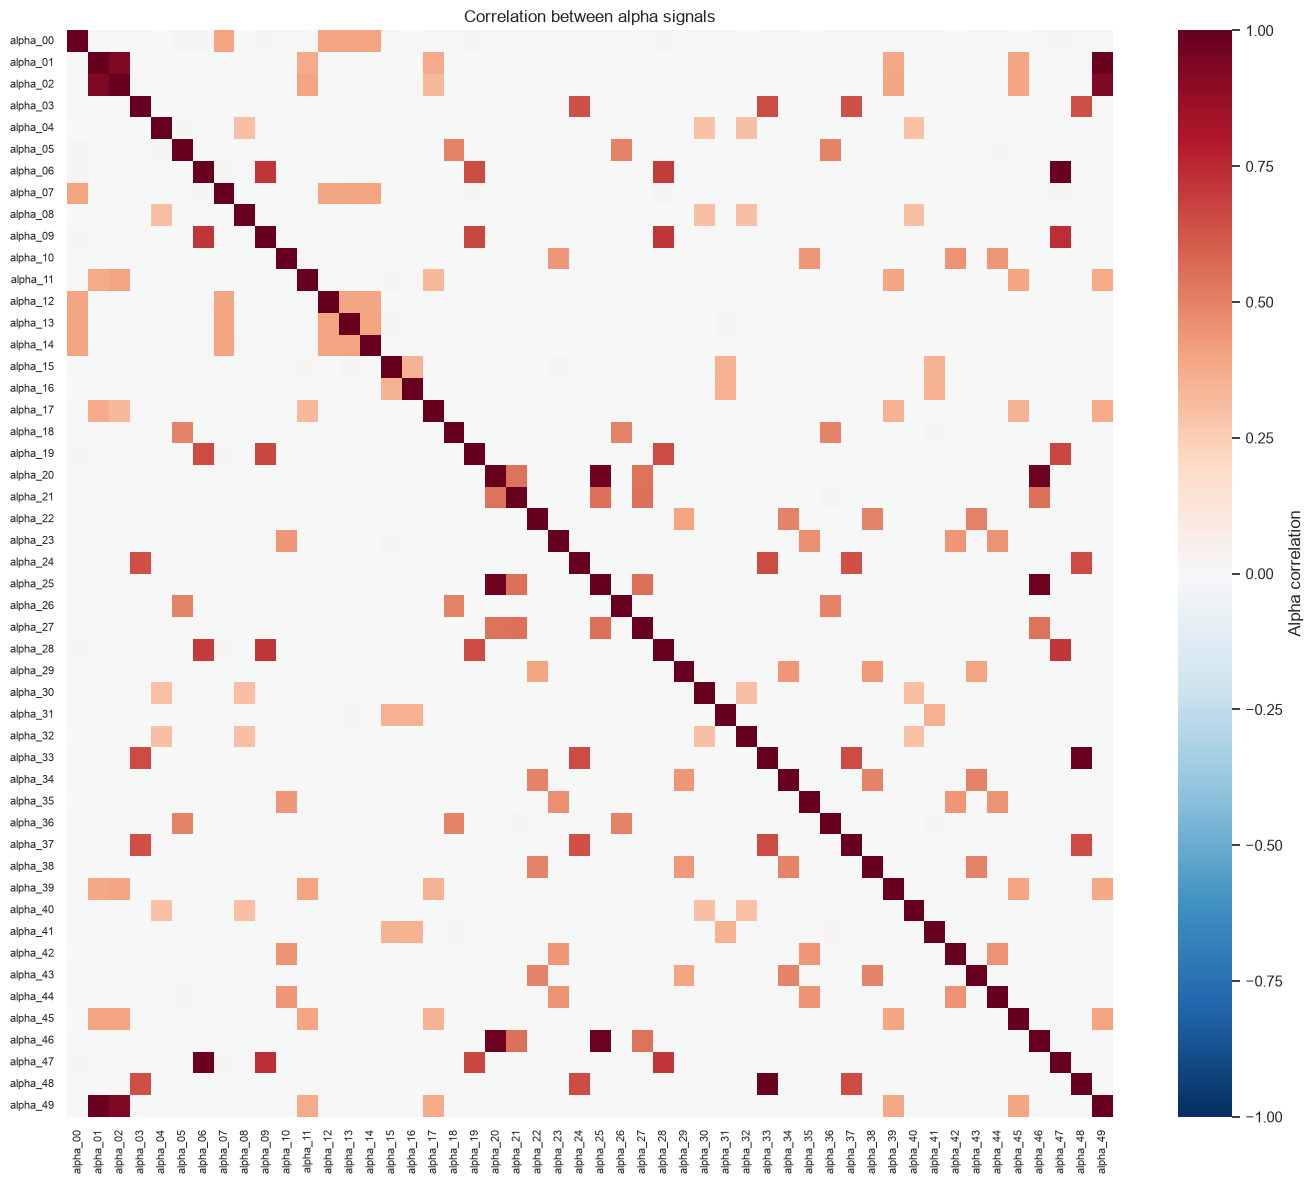

In [8]:
alpha_corr = df_alphas.corr(method="pearson")

plt.figure(figsize=(14, 12))
sns.heatmap(
    alpha_corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=True,
    yticklabels=True,
    cbar_kws={"label": "Alpha correlation"},
)
plt.title("Correlation between alpha signals")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

count    1225.000000
mean        0.042601
std         0.148442
min        -0.013156
25%        -0.001380
50%         0.000813
75%         0.003336
max         0.989974
Name: correlation, dtype: float64

Most positively correlated signals:


,alpha_1,alpha_2,correlation
0,alpha_01,alpha_49,0.989974
1,alpha_33,alpha_48,0.989347
2,alpha_06,alpha_47,0.985596
3,alpha_25,alpha_46,0.977618
4,alpha_20,alpha_46,0.976961
5,alpha_20,alpha_25,0.969727
6,alpha_01,alpha_02,0.934368
7,alpha_02,alpha_49,0.934363
8,alpha_09,alpha_47,0.741948
9,alpha_09,alpha_28,0.717213


Lowest-correlation signals:


,alpha_1,alpha_2,correlation
0,alpha_24,alpha_41,-0.013156
1,alpha_04,alpha_41,-0.012382
2,alpha_15,alpha_33,-0.011102
3,alpha_37,alpha_41,-0.010091
4,alpha_15,alpha_48,-0.009789
5,alpha_33,alpha_41,-0.009550
6,alpha_32,alpha_41,-0.009408
7,alpha_31,alpha_33,-0.009261
8,alpha_31,alpha_48,-0.009138
9,alpha_08,alpha_31,-0.008982


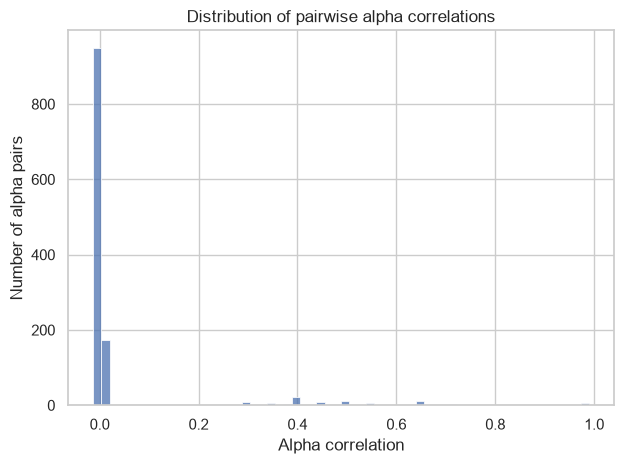

In [9]:
upper_triangle = np.triu(
    np.ones(alpha_corr.shape, dtype=bool), k=1
)

signal_corr = alpha_corr.where(upper_triangle).stack()
signal_corr.index.names = ["alpha_1", "alpha_2"]
signal_corr.name = "correlation"

display(signal_corr.describe())

print("Most positively correlated signals:")
display(signal_corr.nlargest(10).reset_index())

print("Lowest-correlation signals:")
display(signal_corr.nsmallest(10).reset_index())

sns.histplot(signal_corr, bins=60)
plt.title("Distribution of pairwise alpha correlations")
plt.xlabel("Alpha correlation")
plt.ylabel("Number of alpha pairs")
plt.tight_layout()
plt.show()

Most alpha pairs have little linear correlation: the median correlation is 0.0008, and the middle 50% range from −0.0014 to 0.0033. However, several pairs are strongly correlated,these relationships suggest redundancy.

### 3.3 Predictive quality of alpha signals

We measure daily rank IC: the Spearman correlation across stocks between each alpha and forward returns.

We assume returns indexed by date t are already the forward outcomes for signals at t.

In [10]:
forward_returns = (
    df_asset
    .rename_axis(index="date", columns="asset")
    .stack()
    .rename("forward_return")
)


dates = df_asset.index.sort_values()

VALIDATION_DAYS = 504
GAP_DAYS = 1  

research_dates = dates[:-(VALIDATION_DAYS + GAP_DAYS)]
validation_dates = dates[-VALIDATION_DAYS:]

research_alphas = df_alphas.loc[
    df_alphas.index.get_level_values("date").isin(research_dates)
].sort_index()

research_returns = forward_returns.reindex(research_alphas.index)

print("Research:", research_dates.min(), "to", research_dates.max())
print("Validation:", validation_dates.min(), "to", validation_dates.max())

Research: 2012-01-02 00:00:00 to 2019-09-20 00:00:00
Validation: 2019-09-24 00:00:00 to 2021-08-27 00:00:00


In [11]:
return_ranks = research_returns.groupby(level="date").rank()
y = return_ranks - return_ranks.groupby(level="date").transform("mean")
y_squared_sum = y.pow(2).groupby(level="date").sum()

ic_columns = {}

for alpha in research_alphas.columns:
    signal_ranks = research_alphas[alpha].groupby(level="date").rank()
    x = signal_ranks - signal_ranks.groupby(level="date").transform("mean")

    numerator = (x * y).groupby(level="date").sum()
    denominator = np.sqrt(
        x.pow(2).groupby(level="date").sum() * y_squared_sum
    )

    # Constant signals have undefined correlation
    ic_columns[alpha] = numerator / denominator.replace(0, np.nan)

daily_ic = pd.DataFrame(ic_columns)

display(daily_ic.head())

,alpha_00,alpha_01,alpha_02,alpha_03,alpha_04,alpha_05,alpha_06,alpha_07,alpha_08,alpha_09,alpha_10,alpha_11,alpha_12,alpha_13,alpha_14,alpha_15,alpha_16,alpha_17,alpha_18,alpha_19,alpha_20,alpha_21,alpha_22,alpha_23,alpha_24,alpha_25,alpha_26,alpha_27,alpha_28,alpha_29,alpha_30,alpha_31,alpha_32,alpha_33,alpha_34,alpha_35,alpha_36,alpha_37,alpha_38,alpha_39,alpha_40,alpha_41,alpha_42,alpha_43,alpha_44,alpha_45,alpha_46,alpha_47,alpha_48,alpha_49
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012-01-02,0.008387,-0.018726,-0.018520,-0.063334,0.068066,0.043682,-0.063897,0.026798,0.008365,0.006529,-0.033416,0.033393,0.001907,0.051204,0.014316,0.060635,-0.015718,0.042168,0.023133,-0.006283,0.033954,0.035542,-0.073458,0.017847,-0.089138,0.030141,0.027349,0.014453,-0.057296,-0.077277,0.021386,-0.006932,0.017505,-0.084344,-0.066058,0.003455,-0.035248,-0.016272,-0.041772,-0.028485,-0.019870,-0.030486,0.003685,-0.030742,0.028806,-0.018507,0.031767,-0.069426,-0.067734,-0.020101
2012-01-03,0.083754,-0.041731,-0.039703,-0.000846,0.096408,0.000354,0.034489,-0.007649,0.005937,0.060744,-0.012606,-0.047598,0.027568,0.022784,0.039618,-0.027599,0.023309,-0.043000,-0.000251,0.028572,-0.019834,-0.033584,-0.008929,-0.034637,0.029921,-0.012579,-0.024892,-0.037972,0.058195,0.018312,-0.032989,-0.004966,-0.015698,-0.031084,0.034747,0.005769,-0.028343,0.014085,-0.015320,-0.042969,0.008951,0.085704,-0.013049,0.047249,0.029251,0.003646,-0.013882,0.038909,-0.032766,-0.029307
2012-01-04,0.046634,-0.031212,0.009162,0.009546,0.143048,0.000710,-0.081794,-0.028151,0.042531,-0.057173,-0.045244,0.037622,0.013367,-0.071850,-0.034089,-0.026850,0.134844,-0.034402,-0.066896,-0.080467,0.034962,-0.033830,-0.090902,-0.006900,0.013118,0.041355,-0.099448,0.006293,-0.040559,-0.000311,0.031521,0.052102,0.052510,0.025794,-0.012593,-0.024163,-0.085813,0.009914,0.001326,0.038521,0.044488,-0.023650,0.036729,-0.082553,-0.040330,-0.029478,0.026846,-0.085560,0.029607,-0.006968
2012-01-05,0.070128,0.029171,0.034876,-0.029046,0.017515,0.069733,-0.036529,0.084461,-0.096110,-0.042189,0.001204,0.054700,0.040124,-0.020349,-0.020294,-0.012644,-0.044860,0.073614,0.111085,-0.045558,0.016155,0.000089,0.002947,-0.042284,-0.084426,0.023948,0.034217,-0.057709,-0.035849,-0.083236,-0.007344,0.013959,0.059072,-0.084748,-0.021751,0.027569,0.101480,-0.063143,0.030659,0.022193,-0.015889,0.016517,0.050344,0.000598,-0.050047,-0.001954,0.023946,-0.033259,-0.076103,0.036685
2012-01-06,-0.050142,0.045142,0.049813,-0.034759,-0.001683,-0.015579,0.088645,-0.075157,0.049231,0.032198,-0.012234,-0.009125,0.055041,0.023909,-0.056943,0.010751,0.027953,0.029515,0.016466,0.032889,0.021381,0.013903,-0.087146,0.015220,-0.036539,0.024071,0.015315,0.005860,0.063832,-0.067529,0.020469,0.053862,-0.029180,-0.020497,-0.092331,-0.036204,0.010449,-0.010526,-0.003568,-0.026722,0.011693,-0.008849,-0.008090,-0.000495,0.009792,0.030332,0.018291,0.089488,-0.013602,0.035207


In [12]:
ic_summary = pd.DataFrame({
    "mean_ic": daily_ic.mean(),
    "std_ic": daily_ic.std(),
    "valid_days": daily_ic.count(),
    "positive_days_pct": (
        daily_ic.gt(0).sum() / daily_ic.count() * 100
    ),
})

ic_summary["ic_mean_over_std"] = (
    ic_summary["mean_ic"]
    / ic_summary["std_ic"].replace(0, np.nan)
)

# Include potentially useful negative signals
ic_summary["abs_mean_ic"] = ic_summary["mean_ic"].abs()
ic_summary = ic_summary.sort_values("abs_mean_ic", ascending=False)

display(ic_summary)

,mean_ic,std_ic,valid_days,positive_days_pct,ic_mean_over_std,abs_mean_ic
alpha_35,0.016596,0.045660,2015,64.813896,0.363471,0.016596
alpha_30,0.011693,0.045437,2015,59.553350,0.257334,0.011693
alpha_08,0.011123,0.047687,2015,60.297767,0.233256,0.011123
alpha_37,0.010309,0.045582,2015,58.858561,0.226168,0.010309
alpha_12,0.010208,0.045760,2015,59.751861,0.223066,0.010208
alpha_43,0.010104,0.044255,2015,59.057072,0.228321,0.010104
alpha_26,0.009811,0.045629,2015,58.411911,0.215009,0.009811
alpha_04,0.009030,0.043542,2015,57.171216,0.207385,0.009030
alpha_38,0.008967,0.045092,2015,57.816377,0.198869,0.008967
alpha_21,0.008556,0.045629,2015,57.766749,0.187513,0.008556


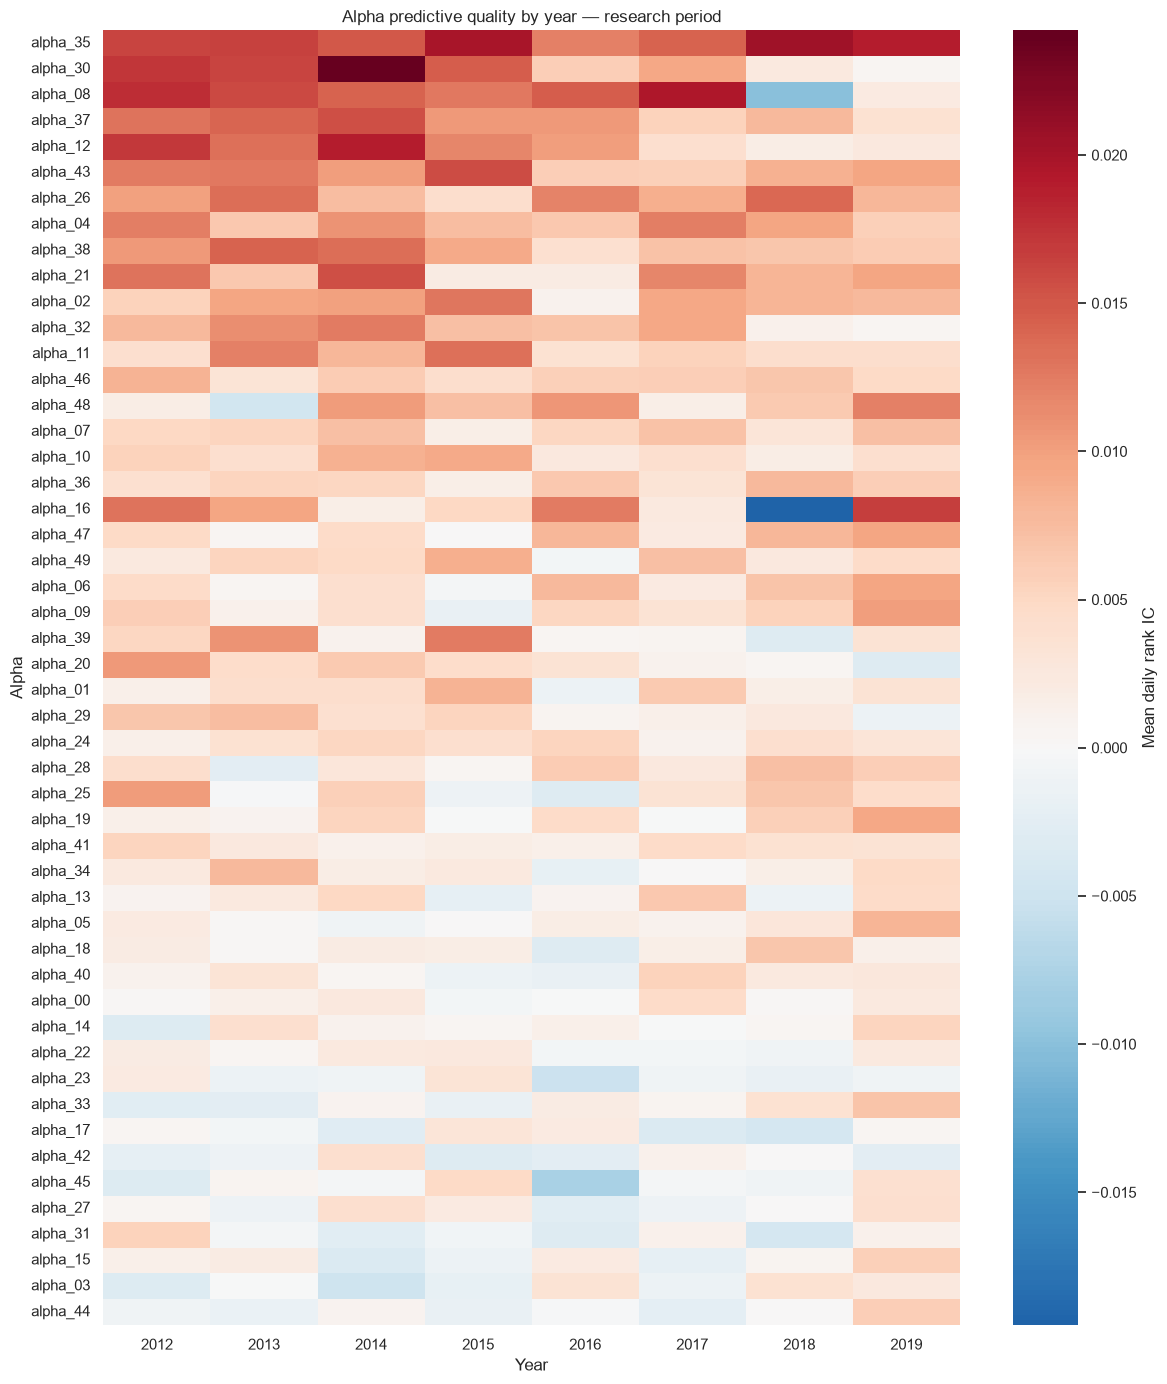

In [13]:
yearly_ic = daily_ic.groupby(daily_ic.index.year).mean()

plt.figure(figsize=(12, 14))
sns.heatmap(
    yearly_ic[ic_summary.index].T,
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "Mean daily rank IC"},
)

plt.title("Alpha predictive quality by year — research period")
plt.xlabel("Year")
plt.ylabel("Alpha")
plt.tight_layout()
plt.show()

The research-period results show substantial differences in predictive
quality across the 50 alphas.

Alpha_35 has the highest mean daily rank IC (0.0166), with positive IC on
64.8% of days. Alpha_30 and alpha_08 follow, with mean ICs of 0.0117 and
0.0111. These are promising candidates for aggregation, although daily
IC variability remains larger than the average predictive relationship.

Several signals, including alpha_44, alpha_03, and alpha_15, have mean
ICs close to zero and positive-day frequencies near 50%, indicating
little standalone predictive evidence from these summary statistics.

Alpha_06, alpha_09, alpha_19, alpha_28, and alpha_47 have noticeably higher
IC variability than most other signals. Their modest positive averages
should therefore be interpreted cautiously.

These findings support comparing combinations that account for both
predictive quality and redundancy. They do not yet establish statistical
significance or profitability after trading costs. Signal selection
should also consider yearly stability before evaluation on validation data.

### 3.4 Alpha stability over time

We examine whether predictive relationships persist across years and rolling windows. All calculations use the research period only.

In [14]:
yearly_ic = daily_ic.groupby(daily_ic.index.year).mean()

stability_summary = ic_summary[
    ["mean_ic", "std_ic", "positive_days_pct"]
].copy()

stability_summary["positive_years"] = yearly_ic.gt(0).sum()
stability_summary["years_observed"] = yearly_ic.count()
stability_summary["worst_year_ic"] = yearly_ic.min()
stability_summary["best_year_ic"] = yearly_ic.max()

display(stability_summary)

,mean_ic,std_ic,positive_days_pct,positive_years,years_observed,worst_year_ic,best_year_ic
alpha_35,0.016596,0.045660,64.813896,8,8,0.012226,0.020353
alpha_30,0.011693,0.045437,59.553350,8,8,0.000450,0.024201
alpha_08,0.011123,0.047687,60.297767,7,8,-0.010078,0.019434
alpha_37,0.010309,0.045582,58.858561,8,8,0.003658,0.015661
alpha_12,0.010208,0.045760,59.751861,8,8,0.001705,0.019013
alpha_43,0.010104,0.044255,59.057072,8,8,0.005605,0.015802
alpha_26,0.009811,0.045629,58.411911,8,8,0.004305,0.013904
alpha_04,0.009030,0.043542,57.171216,8,8,0.005636,0.012399
alpha_38,0.008967,0.045092,57.816377,8,8,0.003813,0.014205
alpha_21,0.008556,0.045629,57.766749,8,8,0.001997,0.015543


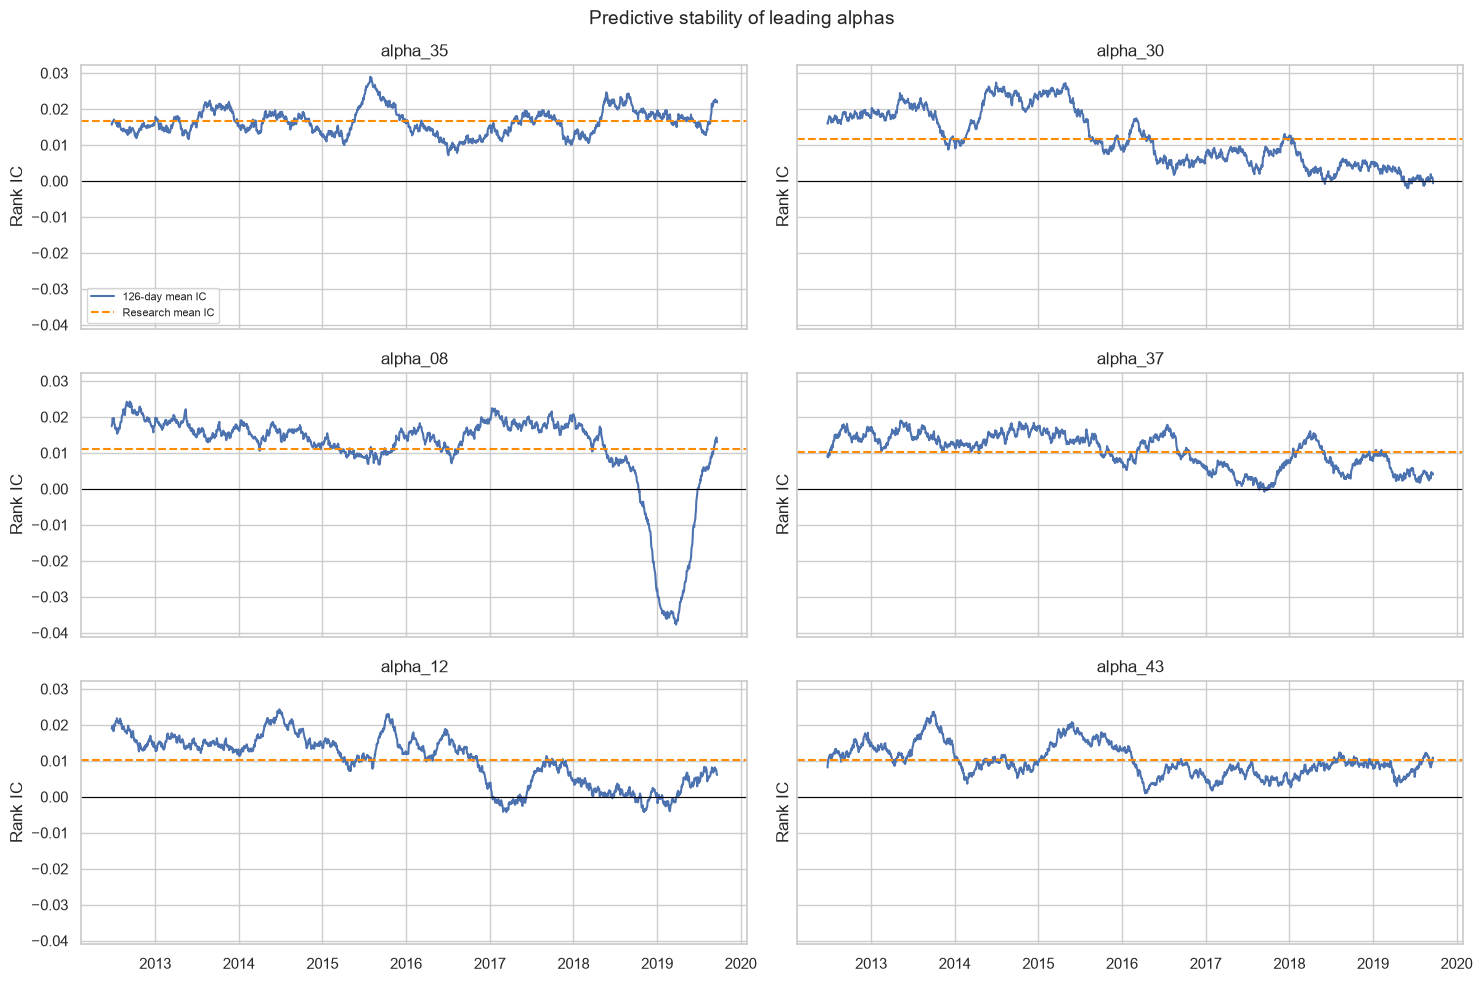

In [15]:
top_alphas = ic_summary.index[:6]
WINDOW = 126  # Approximately six trading months

rolling_ic = daily_ic[top_alphas].rolling(
    window=WINDOW,
    min_periods=WINDOW,
).mean()

fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 10),
    sharex=True,
    sharey=True,
)

for ax, alpha in zip(axes.flat, top_alphas):
    ax.plot(
        rolling_ic.index,
        rolling_ic[alpha],
        label="126-day mean IC",
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(
        daily_ic[alpha].mean(),
        color="darkorange",
        linestyle="--",
        label="Research mean IC",
    )
    ax.set_title(alpha)
    ax.set_ylabel("Rank IC")

axes[0, 0].legend(fontsize=8)
fig.suptitle("Predictive stability of leading alphas", fontsize=14)
plt.tight_layout()
plt.show()

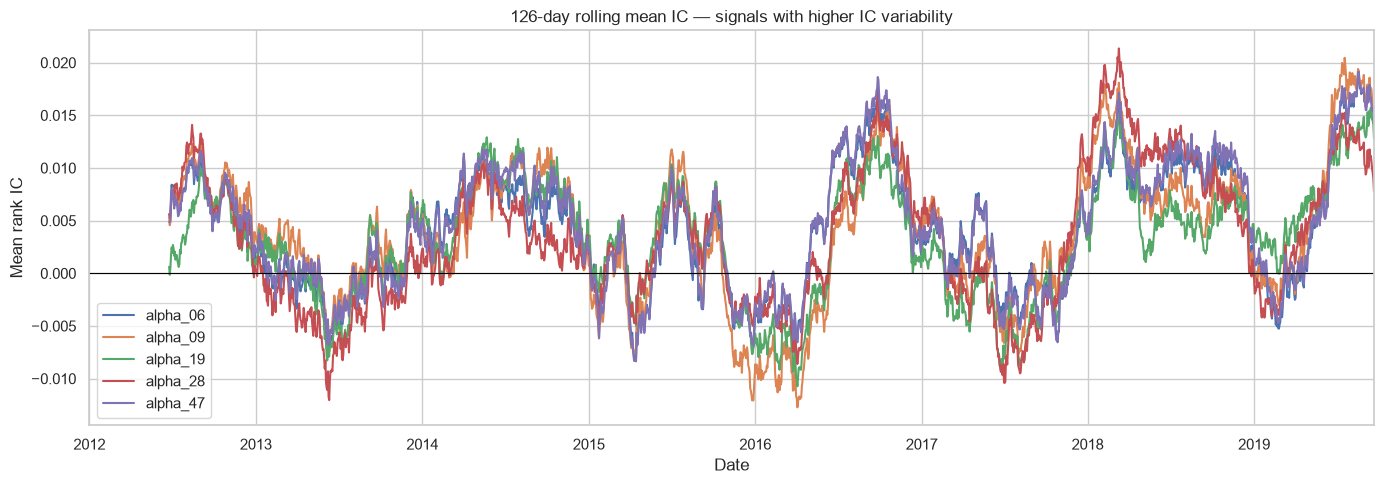

In [16]:
volatile_alphas = ["alpha_06", "alpha_09", "alpha_19", "alpha_28", "alpha_47"]

daily_ic[volatile_alphas].rolling(
    window=WINDOW,
    min_periods=WINDOW,
).mean().plot(figsize=(14, 5))

plt.axhline(0, color="black", linewidth=0.8)
plt.title("126-day rolling mean IC — signals with higher IC variability")
plt.xlabel("Date")
plt.ylabel("Mean rank IC")
plt.tight_layout()
plt.show()

The stability analysis shows that a high average IC does not necessarily
imply persistent predictive strength. Alpha_35 combines the highest mean
IC with positive yearly and rolling averages throughout the research
period. In contrast, alpha_30 weakens toward the end, while alpha_08
experiences a substantial temporary reversal.

Positive yearly averages can also hide weaker intervals: alpha_12 has
positive IC in every observed year but negative rolling IC during some
periods. The higher-variability signals exhibit synchronized fluctuations,
suggesting that combining them may provide limited diversification of
predictive behavior.

These findings motivate comparing aggregation methods that account for
redundancy and changing signal strength. They remain research-period
observations, not evidence of future profitability.

## 4. Equal-weight alpha baseline

The 50 alpha signals are already normalized across stocks on each date,
with means approximately zero and standard deviations approximately one.

We average them directly, giving each signal equal weight, without
additional normalization or sign reversals. We evaluate the combined
signal's predictive quality on the research period only.

In [17]:
# Combine the 50 already-normalized alphas with equal weights
equal_weight_signal = research_alphas.mean(axis=1)
equal_weight_signal.name = "equal_weight"

display(equal_weight_signal.head())

date        asset
2012-01-02  A000     0.352089
            A001    -0.432068
            A002     0.175062
            A003     0.147211
            A004     0.256249
Name: equal_weight, dtype: float64

In [18]:
baseline_ranks = equal_weight_signal.groupby(level="date").rank()

return_ranks = (
    research_returns.reindex(equal_weight_signal.index)
    .groupby(level="date")
    .rank()
)

x = baseline_ranks - baseline_ranks.groupby(level="date").transform("mean")
y = return_ranks - return_ranks.groupby(level="date").transform("mean")

numerator = (x * y).groupby(level="date").sum()
denominator = np.sqrt(
    x.pow(2).groupby(level="date").sum()
    * y.pow(2).groupby(level="date").sum()
)

baseline_ic = numerator / denominator.replace(0, np.nan)
baseline_ic.name = "equal_weight"

In [19]:
comparison_ic = daily_ic.join(baseline_ic)

baseline_comparison = pd.DataFrame({
    "mean_ic": comparison_ic.mean(),
    "std_ic": comparison_ic.std(),
    "valid_days": comparison_ic.count(),
    "positive_days_pct": (
        comparison_ic.gt(0).sum() / comparison_ic.count() * 100
    ),
})

baseline_comparison["ic_mean_over_std"] = (
    baseline_comparison["mean_ic"]
    / baseline_comparison["std_ic"].replace(0, np.nan)
)

# Show the baseline alongside the six leading individual alphas
comparison_names = ["equal_weight"] + ic_summary.index[:6].tolist()
display(baseline_comparison.loc[comparison_names])

,mean_ic,std_ic,valid_days,positive_days_pct,ic_mean_over_std
equal_weight,0.017583,0.052934,2015,63.225806,0.332164
alpha_35,0.016596,0.045660,2015,64.813896,0.363471
alpha_30,0.011693,0.045437,2015,59.553350,0.257334
alpha_08,0.011123,0.047687,2015,60.297767,0.233256
alpha_37,0.010309,0.045582,2015,58.858561,0.226168
alpha_12,0.010208,0.045760,2015,59.751861,0.223066
alpha_43,0.010104,0.044255,2015,59.057072,0.228321


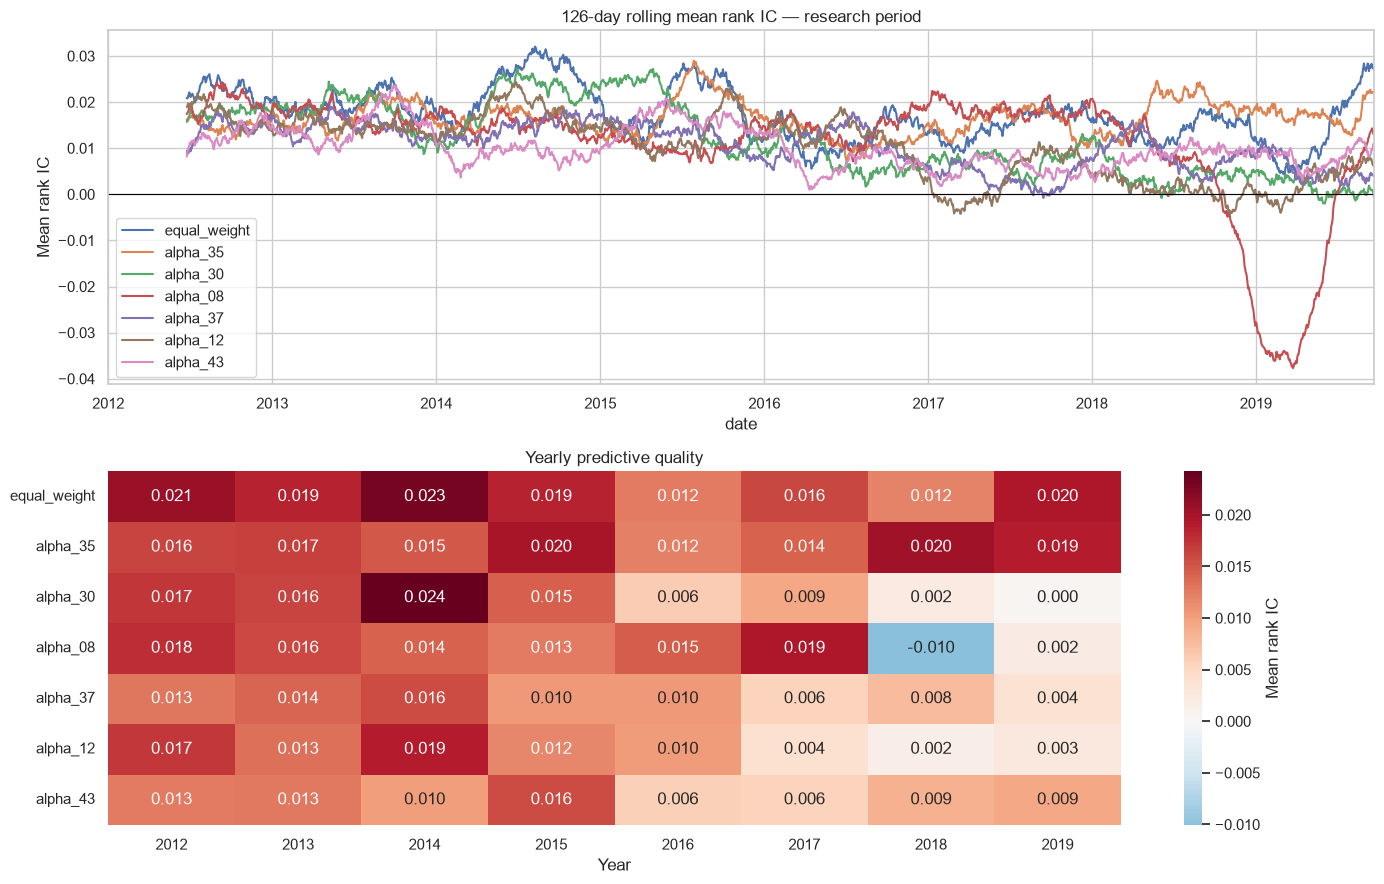

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

comparison_ic[comparison_names].rolling(
    window=126,
    min_periods=126,
).mean().plot(ax=axes[0])

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("126-day rolling mean rank IC — research period")
axes[0].set_ylabel("Mean rank IC")

yearly_comparison = (
    comparison_ic[comparison_names]
    .groupby(comparison_ic.index.year)
    .mean()
)

sns.heatmap(
    yearly_comparison.T,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    ax=axes[1],
    cbar_kws={"label": "Mean rank IC"},
)

axes[1].set_title("Yearly predictive quality")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

### 4.1 Simple signal backtest

We multiply the equal-weight signal by the corresponding forward return
and sum across stocks each day. We calculate cumulative P&L, annualized
Sharpe and Sortino ratios, and maximum drawdown in cumulative P&L units.

We assume same-date returns are already forward returns for the signals.
Trading costs and exposure constraints are not included.

In [21]:
aligned_returns = research_returns.reindex(equal_weight_signal.index)

# Daily P&L: sum across stocks, then accumulate across dates
daily_pnl = (
    equal_weight_signal.mul(aligned_returns)
    .groupby(level="date")
    .sum()
    .sort_index()
)

cumulative_pnl = daily_pnl.cumsum()

# Include starting P&L of zero when measuring drawdown
running_peak = cumulative_pnl.cummax().clip(lower=0)
drawdown = cumulative_pnl - running_peak
max_drawdown = -drawdown.min()

# Annualization assumes 252 observations/year and one-day returns.
# Both ratios use a zero daily benchmark/target.
ANNUALIZATION = 252

pnl_std = daily_pnl.std(ddof=1)
downside_deviation = np.sqrt(
    daily_pnl.clip(upper=0).pow(2).mean()
)

sharpe = (
    np.sqrt(ANNUALIZATION) * daily_pnl.mean() / pnl_std
    if pnl_std > 0 else np.nan
)

sortino = (
    np.sqrt(ANNUALIZATION) * daily_pnl.mean() / downside_deviation
    if downside_deviation > 0 else np.nan
)

metrics = pd.Series({
    "Sharpe ratio": sharpe,
    "Sortino ratio": sortino,
    "Maximum drawdown (P&L units)": max_drawdown,
    "Total cumulative P&L": cumulative_pnl.iloc[-1],
    "Number of days": len(daily_pnl),
})

display(metrics.to_frame("Gross research backtest"))

,Gross research backtest
Sharpe ratio,5.521924
Sortino ratio,10.717599
Maximum drawdown (P&L units),1.287738
Total cumulative P&L,70.344697
Number of days,2015.000000


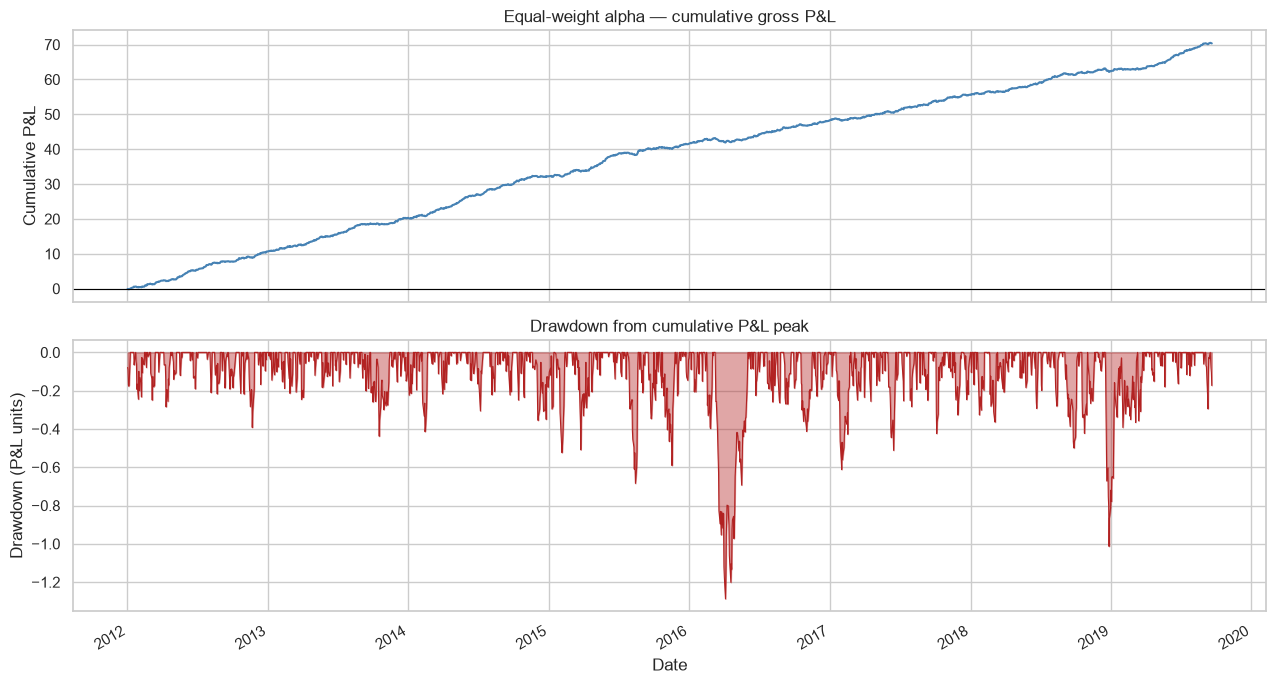

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

dates_plot = cumulative_pnl.index.to_pydatetime()

axes[0].plot(
    dates_plot,
    cumulative_pnl.to_numpy(),
    color="steelblue",
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Equal-weight alpha — cumulative gross P&L")
axes[0].set_ylabel("Cumulative P&L")

axes[1].plot(
    dates_plot,
    drawdown.to_numpy(),
    color="firebrick",
    linewidth=0.8,
)
axes[1].fill_between(
    dates_plot,
    drawdown.to_numpy(),
    0,
    color="firebrick",
    alpha=0.4,
)
axes[1].set_title("Drawdown from cumulative P&L peak")
axes[1].set_ylabel("Drawdown (P&L units)")
axes[1].set_xlabel("Date")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The equal-weight signal produces a gross research-period Sharpe ratio
of 5.52 and Sortino ratio of 10.72 across 2,015 days. Cumulative raw-signal
P&L reaches 70.34, with a maximum drawdown of 1.29 P&L units.

These results suggest a positive historical relationship between the
combined signal and forward returns. However, exposures are not scaled
to a fixed capital base, so cumulative P&L and drawdown should not be
interpreted as percentage returns.

This backtest excludes trading costs and uses the research period.
It therefore establishes a gross baseline rather than demonstrating
out-of-sample, implementable profitability.

### 4.2 Turnover and trading-cost sensitivity

We convert the combined signal into portfolio weights with zero net
exposure and unit gross exposure (sum of absolute weights equals one).

Turnover measures total absolute traded weight, including adjustments
for positions drifting with returns. Initial portfolio entry is charged.

We compare costs of 0, 1, 2, and 5 basis points per unit traded.
These are illustrative scenarios. Borrow fees, financing, and market
impact beyond the assumed proportional costs are excluded.

In [23]:
signal_matrix = equal_weight_signal.unstack("asset").sort_index()

# Dollar-neutral targets with gross exposure of 1
centered_signal = signal_matrix.sub(signal_matrix.mean(axis=1), axis=0)
gross_signal = centered_signal.abs().sum(axis=1)

weights = centered_signal.div(
    gross_signal.replace(0, np.nan), axis=0
).fillna(0.0)

portfolio_forward_returns = df_asset.reindex(
    index=weights.index,
    columns=weights.columns,
)

gross_returns = weights.mul(portfolio_forward_returns).sum(axis=1)

print("Maximum absolute net exposure:", weights.sum(axis=1).abs().max())
print("Average gross exposure:", weights.abs().sum(axis=1).mean())
print("Largest absolute stock weight:", weights.abs().max().max())

Maximum absolute net exposure: 1.3270634591222574e-16
Average gross exposure: 1.0
Largest absolute stock weight: 0.011948774913787838


In [24]:
COST_SCENARIOS_BPS = [0, 1, 2, 5]
ANNUALIZATION = 252

target_array = weights.to_numpy()
return_array = portfolio_forward_returns.to_numpy()

net_returns = pd.DataFrame(index=weights.index)
turnover_by_scenario = pd.DataFrame(index=weights.index)

for cost_bps in COST_SCENARIOS_BPS:
    cost_rate = cost_bps / 10_000
    pretrade_weights = np.zeros(weights.shape[1])

    scenario_returns = []
    scenario_turnover = []

    for target, asset_returns in zip(target_array, return_array):
        # Total buys + sells; no division by two
        traded_weight = np.abs(target - pretrade_weights).sum()
        trading_cost = cost_rate * traded_weight

        gross_return = np.dot(target, asset_returns)
        net_return = gross_return - trading_cost

        if 1 + net_return <= 0:
            raise ValueError("Portfolio capital became non-positive.")

        scenario_returns.append(net_return)
        scenario_turnover.append(traded_weight)

        # Positions after returns, expressed as fractions of ending capital
        pretrade_weights = (
            target * (1 + asset_returns) / (1 + net_return)
        )

    label = f"{cost_bps} bps"
    net_returns[label] = scenario_returns
    turnover_by_scenario[label] = scenario_turnover

In [25]:
def summarize_portfolio(returns_series):
    daily_std = returns_series.std(ddof=1)
    downside = np.sqrt(returns_series.clip(upper=0).pow(2).mean())

    equity = (1 + returns_series).cumprod()
    peak = equity.cummax().clip(lower=1.0)
    drawdown_pct = equity.div(peak) - 1

    return pd.Series({
        "Annualized Sharpe": (
            np.sqrt(ANNUALIZATION) * returns_series.mean() / daily_std
            if daily_std > 0 else np.nan
        ),
        "Annualized Sortino": (
            np.sqrt(ANNUALIZATION) * returns_series.mean() / downside
            if downside > 0 else np.nan
        ),
        "Total return (%)": (equity.iloc[-1] - 1) * 100,
        "Maximum drawdown (%)": -drawdown_pct.min() * 100,
    })


cost_comparison = net_returns.apply(summarize_portfolio).T

cost_comparison["Average daily traded weight (%)"] = (
    turnover_by_scenario.mean() * 100
)

display(cost_comparison.round(3))

,Annualized Sharpe,Annualized Sortino,Total return (%),Maximum drawdown (%),Average daily traded weight (%)
0 bps,5.530,10.743,103.300,1.274,47.298
1 bps,4.788,8.908,84.824,1.361,47.299
2 bps,4.047,7.215,68.026,1.453,47.300
5 bps,1.821,2.872,26.243,2.199,47.303


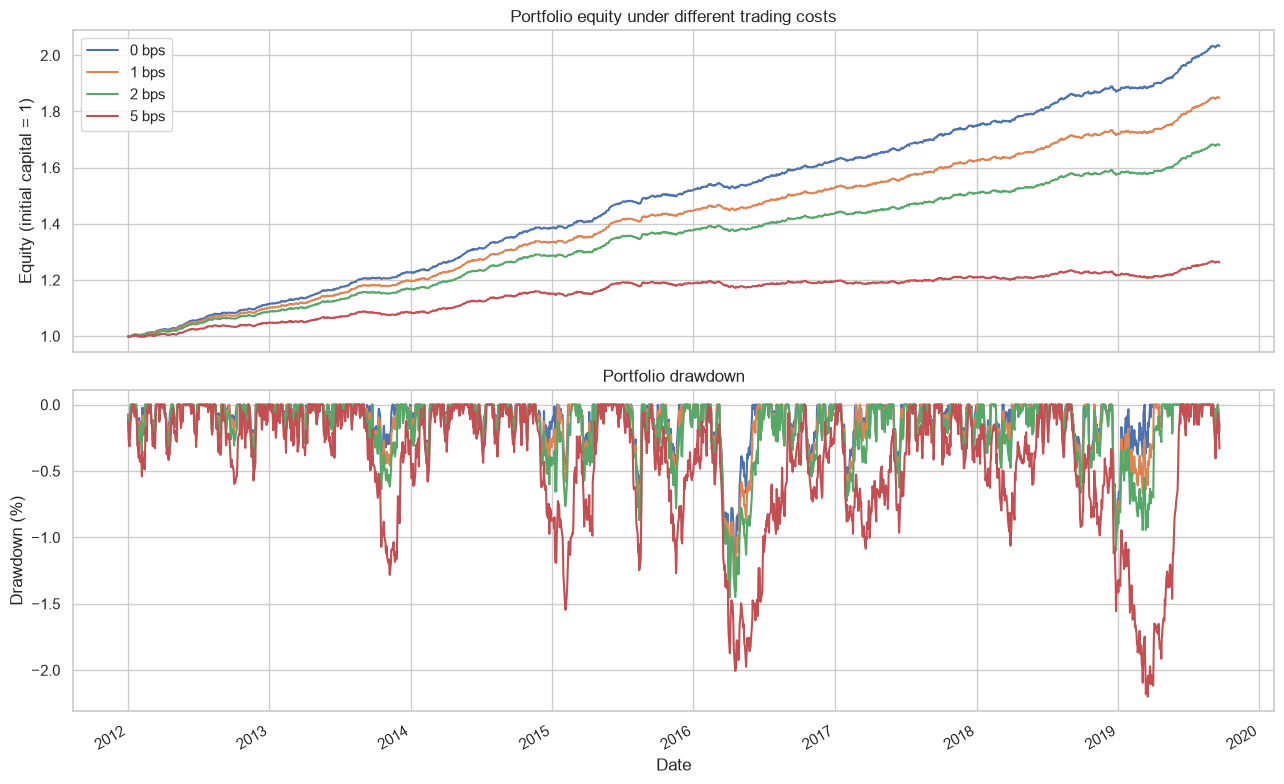

In [26]:
equity_curves = (1 + net_returns).cumprod()
equity_peaks = equity_curves.cummax().clip(lower=1.0)
drawdowns_pct = (equity_curves / equity_peaks - 1) * 100

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
plot_dates = equity_curves.index.to_pydatetime()

for label in equity_curves.columns:
    axes[0].plot(
        plot_dates, equity_curves[label].to_numpy(), label=label
    )
    axes[1].plot(
        plot_dates, drawdowns_pct[label].to_numpy(), label=label
    )

axes[0].set_title("Portfolio equity under different trading costs")
axes[0].set_ylabel("Equity (initial capital = 1)")
axes[0].legend()

axes[1].set_title("Portfolio drawdown")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The portfolio maintains approximately zero net exposure and unit gross
exposure, with a maximum observed absolute stock weight of 1.19%.

Average daily traded weight is approximately 47.3% of portfolio equity,
counting buys and sells together. This creates substantial sensitivity
to transaction costs: Sharpe falls from 5.53 before costs to 1.82 at
5 basis points per unit traded, while maximum drawdown increases from
1.27% to 2.20%.

The baseline remains profitable under all tested cost scenarios over
the research period. However, these are illustrative cost assumptions,
and the results exclude borrowing and financing costs and have not
yet been evaluated on the reserved validation period.

The next experiment should test whether smoothing the combined signal
reduces turnover enough to improve net performance despite potentially
weakening its predictive responsiveness.

### 4.3 Signal smoothing and turnover reduction

We smooth each stock's combined signal using an exponentially weighted
moving average of current and past observations.

We compare no smoothing with half-lives of 1, 3, and 5 trading days.
Each strategy maintains zero net exposure and unit gross exposure.

The objective is to determine whether lower trading costs compensate
for slower responses to new signals. These research-period comparisons
are exploratory; the reserved validation period remains unused.

In [27]:
signal_matrix = equal_weight_signal.unstack("asset").sort_index()

HALF_LIVES = {
    "No smoothing": None,
    "1-day half-life": 1,
    "3-day half-life": 3,
    "5-day half-life": 5,
}

weights_by_strategy = {}

for strategy, half_life in HALF_LIVES.items():
    if half_life is None:
        signal = signal_matrix.copy()
    else:
        signal = signal_matrix.ewm(
            halflife=half_life,
            adjust=False,
        ).mean()

    centered = signal.sub(signal.mean(axis=1), axis=0)
    gross = centered.abs().sum(axis=1)

    weights_by_strategy[strategy] = centered.div(
        gross.replace(0, np.nan), axis=0
    ).fillna(0.0)

backtest_returns = df_asset.reindex(
    index=signal_matrix.index,
    columns=signal_matrix.columns,
)

In [28]:
COST_SCENARIOS_BPS = [0, 1, 2, 5]

smoothing_results = []
smoothing_returns = {}

asset_return_array = backtest_returns.to_numpy()

for strategy, strategy_weights in weights_by_strategy.items():
    for cost_bps in COST_SCENARIOS_BPS:
        cost_rate = cost_bps / 10_000
        pretrade_weights = np.zeros(strategy_weights.shape[1])

        daily_net = []
        daily_traded = []

        for target, asset_returns in zip(
            strategy_weights.to_numpy(),
            asset_return_array,
        ):
            traded_weight = np.abs(target - pretrade_weights).sum()
            cost = cost_rate * traded_weight

            gross_return = np.dot(target, asset_returns)
            net_return = gross_return - cost

            if 1 + net_return <= 0:
                raise ValueError("Portfolio capital became non-positive.")

            daily_net.append(net_return)
            daily_traded.append(traded_weight)

            pretrade_weights = (
                target * (1 + asset_returns) / (1 + net_return)
            )

        result_returns = pd.Series(
            daily_net,
            index=strategy_weights.index,
            name=strategy,
        )

        smoothing_returns[(strategy, cost_bps)] = result_returns

        metrics = summarize_portfolio(result_returns).to_dict()
        metrics.update({
            "Strategy": strategy,
            "Cost (bps)": cost_bps,
            "Average daily traded weight (%)": np.mean(daily_traded) * 100,
        })
        smoothing_results.append(metrics)

smoothing_comparison = (
    pd.DataFrame(smoothing_results)
    .set_index(["Strategy", "Cost (bps)"])
)

display(smoothing_comparison.round(3))

Annualized Sharpe  Annualized Sortino  \
Strategy        Cost (bps)                                          
No smoothing    0                       5.530              10.743   
                1                       4.788               8.908   
                2                       4.047               7.215   
                5                       1.821               2.872   
1-day half-life 0                       5.262              10.082   
                1                       4.853               9.078   
                2                       4.444               8.118   
                5                       3.216               5.479   
3-day half-life 0                       4.356               7.914   
                1                       4.137               7.422   
                2                       3.918               6.941   
                5                       3.259               5.565   
5-day half-life 0                       3.719               6.510   
                1                       3.559               6.172   
                2                       3.398               5.840   
                5                       2.915               4.878   

                            Total return (%)  Maximum drawdown (%)  \
Strategy        Cost (bps)                                           
No smoothing    0                    103.300                 1.274   
                1                     84.824                 1.361   
                2                     68.026                 1.453   
                5                     26.243                 2.199   
1-day half-life 0                     99.399                 1.313   
                1                     88.966                 1.364   
                2                     79.078                 1.416   
                5                     52.411                 1.618   
3-day half-life 0                     80.020                 1.360   
                1                     74.762                 1.388   
                2                     69.657                 1.431   
                5                     55.221                 1.580   
5-day half-life 0                     66.691                 1.441   
                1                     63.043                 1.478   
                2                     59.475                 1.515   
                5                     49.232                 1.627   

                            Average daily traded weight (%)  
Strategy        Cost (bps)                                   
No smoothing    0                                    47.298  
                1                                    47.299  
                2                                    47.300  
                5                                    47.303  
1-day half-life 0                                    26.678  
                1                                    26.679  
                2                                    26.679  
                5                                    26.680  
3-day half-life 0                                    14.715  
                1                                    14.715  
                2                                    14.715  
                5                                    14.715  
5-day half-life 0                                    10.984  
                1                                    10.984  
                2                                    10.984  
                5                                    10.984

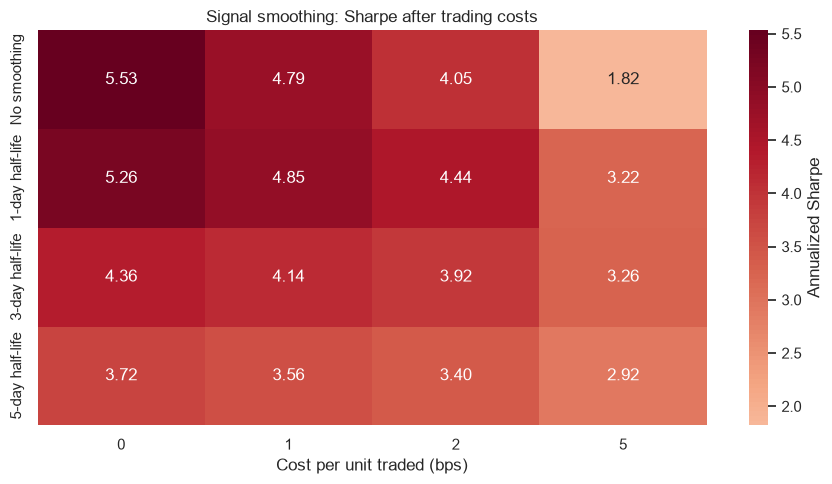

In [29]:
sharpe_table = (
    smoothing_comparison["Annualized Sharpe"]
    .unstack("Cost (bps)")
    .reindex(HALF_LIVES)
)

plt.figure(figsize=(9, 5))
sns.heatmap(
    sharpe_table,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "Annualized Sharpe"},
)
plt.title("Signal smoothing: Sharpe after trading costs")
plt.xlabel("Cost per unit traded (bps)")
plt.ylabel("")
plt.tight_layout()
plt.show()

,Annualized Sharpe,Annualized Sortino,Total return (%),Maximum drawdown (%),Average daily traded weight (%)
Strategy,,,,,
No smoothing,1.821,2.872,26.243,2.199,47.303
1-day half-life,3.216,5.479,52.411,1.618,26.680
3-day half-life,3.259,5.565,55.221,1.580,14.715
5-day half-life,2.915,4.878,49.232,1.627,10.984


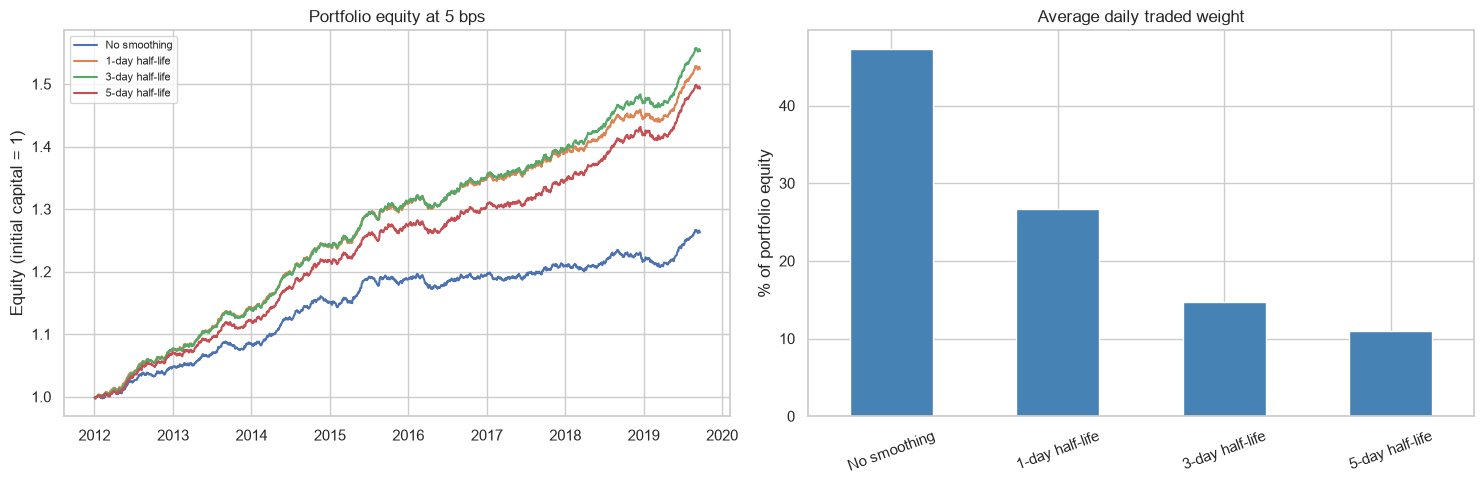

In [30]:
SELECTED_COST_BPS = 5

returns_at_cost = pd.DataFrame({
    strategy: smoothing_returns[(strategy, SELECTED_COST_BPS)]
    for strategy in HALF_LIVES
})

equity_at_cost = (1 + returns_at_cost).cumprod()

comparison_at_cost = (
    smoothing_comparison
    .xs(SELECTED_COST_BPS, level="Cost (bps)")
    .reindex(HALF_LIVES)
)

display(comparison_at_cost.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for strategy in equity_at_cost:
    axes[0].plot(
        equity_at_cost.index.to_pydatetime(),
        equity_at_cost[strategy].to_numpy(),
        label=strategy,
    )

axes[0].set_title(f"Portfolio equity at {SELECTED_COST_BPS} bps")
axes[0].set_ylabel("Equity (initial capital = 1)")
axes[0].legend(fontsize=8)

comparison_at_cost["Average daily traded weight (%)"].plot.bar(
    ax=axes[1],
    color="steelblue",
    rot=20,
)
axes[1].set_title("Average daily traded weight")
axes[1].set_ylabel("% of portfolio equity")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

Smoothing reduces trading activity substantially. Average daily traded
weight falls from 47.3% without smoothing to 26.7%, 14.7%, and 11.0%
for half-lives of 1, 3, and 5 days, respectively.

This reduction comes at the expense of gross predictive performance:
before costs, Sharpe declines as smoothing increases. However, at
5 bps per unit traded, a 3-day half-life improves net Sharpe from 1.82
to 3.26 and reduces maximum drawdown from 2.20% to 1.58%.

The preferred setting depends on trading costs. The 1-day half-life
has the highest Sharpe among the tested strategies at 1 and 2 bps,
while the 3-day half-life narrowly leads at 5 bps. Extending smoothing
to 5 days reduces turnover further but lowers net Sharpe, suggesting
that slower responses sacrifice too much useful signal information.

These results support moderate smoothing as a candidate improvement.
The small Sharpe difference between 1-day and 3-day smoothing at 5 bps
does not establish a reliable winner. Final selection requires
chronological testing within the research period before evaluation
on the reserved validation data.

### 4.4 Market-exposure control

#### 4.4.1 Measure the original baseline's market exposure

We use the average return of the 500 stocks as an internal market proxy.

We measure how the baseline's gross portfolio returns move with this
proxy. This is a historical diagnostic, not a constraint on positions
or a forecast of future market exposure.

In [31]:
# Align stock returns with the baseline positions
exposure_returns = df_asset.reindex(
    index=weights.index,
    columns=weights.columns,
)

# Market proxy: average return across the 500 stocks
market_proxy = exposure_returns.mean(axis=1)

# Baseline portfolio return before trading costs
baseline_gross_returns = weights.mul(exposure_returns).sum(axis=1)

# Historical sensitivity to the market proxy
realized_beta = (
    baseline_gross_returns.cov(market_proxy)
    / market_proxy.var()
)

market_correlation = baseline_gross_returns.corr(market_proxy)

exposure_diagnostics = pd.Series({
    "Average long exposure": weights.clip(lower=0).sum(axis=1).mean(),
    "Average short exposure": weights.clip(upper=0).sum(axis=1).mean(),
    "Maximum absolute net exposure": weights.sum(axis=1).abs().max(),
    "Historical beta to market proxy": realized_beta,
    "Correlation with market proxy": market_correlation,
})

display(exposure_diagnostics.to_frame("Original baseline"))

,Original baseline
Average long exposure,5.000000e-01
Average short exposure,-5.000000e-01
Maximum absolute net exposure,1.327063e-16
Historical beta to market proxy,1.133166e-01
Correlation with market proxy,5.279835e-01


The baseline has balanced long and short exposures of +50% and −50%,
giving effectively zero net exposure. It is therefore dollar-neutral.

However, its historical beta to the universe return proxy is 0.113,
and its correlation with that proxy is 0.528. Equal long and short
amounts therefore do not fully offset their market sensitivities.

These results indicate positive historical exposure to common market
movements. They motivate comparing the baseline with a portfolio that
also controls estimated beta. The proxy represents our 500-stock
universe rather than an external broad-market index.

#### 4.4.2 Estimate each stock's market beta

For each date, we estimate each stock's beta using the previous
252 eligible daily observations:

    beta = covariance(stock returns, market proxy) / variance(market proxy)

We assume the supplied returns are one-day forward returns. We shift
them by two rows so positions at date t use outcomes indexed no later
than t−2, preserving our conservative one-date gap.

The initial dates without sufficient history are excluded from the
subsequent portfolio comparison.

In [32]:
BETA_WINDOW = 252
RETURN_LAG = 2

# Past observations only, under the one-day forward-return assumption
historical_returns = exposure_returns.sort_index().shift(RETURN_LAG)
historical_market = market_proxy.sort_index().shift(RETURN_LAG)

# Rolling covariance of each stock with the market proxy
stock_market_covariance = historical_returns.rolling(
    window=BETA_WINDOW,
    min_periods=BETA_WINDOW,
).cov(historical_market)

# Rolling variance of the market proxy
market_variance = historical_market.rolling(
    window=BETA_WINDOW,
    min_periods=BETA_WINDOW,
).var()

# One estimated beta per date and stock
stock_betas = stock_market_covariance.div(
    market_variance.where(market_variance > 1e-12),
    axis=0,
)

# Keep dates where every stock has a valid estimate
eligible_dates = np.isfinite(stock_betas.to_numpy()).all(axis=1)
estimated_betas = stock_betas.loc[eligible_dates]

print(f"Dates with complete beta estimates: {len(estimated_betas):,}")
print(
    "Estimation coverage:",
    estimated_betas.index.min().date(),
    "to",
    estimated_betas.index.max().date(),
)

# Example: first 10 stocks on the first eligible date
display(
    estimated_betas.iloc[0]
    .rename("Estimated beta")
    .to_frame()
    .head(10)
)

Dates with complete beta estimates: 1,762
Estimation coverage: 2012-12-20 to 2019-09-20


,Estimated beta
asset,
A000,0.487972
A001,1.133652
A002,1.572190
A003,0.772103
A004,0.659562
A005,0.986259
A006,1.049559
A007,1.162581
A008,0.781631


#### 4.4.3 Construct an estimated beta-neutral baseline

We adjust the original stock weights so they satisfy two constraints:

- Zero net exposure: sum of stock weights equals zero.
- Zero estimated market exposure: sum of stock weights × estimated
  stock betas equals zero.

We then rescale to unit gross exposure. This changes the stock positions,
while leaving the alpha signals and observed returns unchanged.

Neutrality is relative to our historical beta estimates and internal
market proxy; realized market exposure may still differ from zero.

In [33]:
original_weights = weights.reindex(
    index=estimated_betas.index,
    columns=estimated_betas.columns,
)

# Ensure the starting weights have zero net exposure
original_weights = original_weights.sub(
    original_weights.mean(axis=1),
    axis=0,
)

In [34]:
# Center betas so the adjustment preserves zero net exposure
centered_betas = estimated_betas.sub(
    estimated_betas.mean(axis=1),
    axis=0,
)

# Measure how strongly the original positions align with stock betas
beta_squared_sum = centered_betas.pow(2).sum(axis=1)

adjustment_size = (
    original_weights.mul(centered_betas).sum(axis=1)
    / beta_squared_sum.where(beta_squared_sum > 1e-12)
).fillna(0.0)

# Remove that exposure
adjusted_weights = original_weights - centered_betas.mul(
    adjustment_size,
    axis=0,
)

# Remove numerical residuals in net exposure
adjusted_weights = adjusted_weights.sub(
    adjusted_weights.mean(axis=1),
    axis=0,
)

# Restore gross exposure to 1; use cash if the remaining signal is negligible
adjusted_gross = adjusted_weights.abs().sum(axis=1)

beta_neutral_weights = adjusted_weights.div(
    adjusted_gross.where(adjusted_gross > 1e-12),
    axis=0,
).fillna(0.0)

In [35]:
estimated_portfolio_beta = pd.DataFrame({
    "Original baseline": (
        original_weights.mul(estimated_betas).sum(axis=1)
    ),
    "Estimated beta-neutral": (
        beta_neutral_weights.mul(estimated_betas).sum(axis=1)
    ),
})

comparison = pd.DataFrame({
    name: {
        "Average net exposure": target.sum(axis=1).mean(),
        "Maximum absolute net exposure": target.sum(axis=1).abs().max(),
        "Average gross exposure": target.abs().sum(axis=1).mean(),
        "Average estimated beta": estimated_portfolio_beta[name].mean(),
        "Maximum absolute estimated beta": (
            estimated_portfolio_beta[name].abs().max()
        ),
    }
    for name, target in {
        "Original baseline": original_weights,
        "Estimated beta-neutral": beta_neutral_weights,
    }.items()
}).T

np.testing.assert_allclose(
    beta_neutral_weights.sum(axis=1), 0, atol=1e-10
)
np.testing.assert_allclose(
    estimated_portfolio_beta["Estimated beta-neutral"], 0, atol=1e-10
)

display(comparison)

,Average net exposure,Maximum absolute net exposure,Average gross exposure,Average estimated beta,Maximum absolute estimated beta
Original baseline,-1.481913e-19,6.310057e-17,1.0,1.048731e-01,1.615079e-01
Estimated beta-neutral,-1.123051e-18,2.717688e-16,1.0,-1.192996e-18,3.597654e-16


The adjusted portfolio satisfies both dollar-neutrality and estimated
beta-neutrality while maintaining unit gross exposure. The original
baseline has an average estimated beta of 0.105, whereas the adjusted
portfolio's estimated beta is effectively zero throughout the period.

These checks confirm the intended portfolio constraints. They do not
guarantee zero realized market exposure, because historical beta
estimates may differ from future sensitivities.

#### 4.4.4 Compare performance after trading costs

We backtest the original and estimated beta-neutral portfolios on
identical dates, starting both from cash.

Transaction costs apply to total absolute traded weight, including
initial entry and adjustments for return-driven position drift.
No terminal liquidation is charged.

We compare performance at 0, 1, 2, and 5 basis points per unit traded.
The objective is to measure the cost and performance implications
of controlling estimated market exposure.

In [36]:
beta_portfolios = {
    "Original baseline": original_weights,
    "Estimated beta-neutral": beta_neutral_weights,
}

beta_test_returns = df_asset.reindex(
    index=original_weights.index,
    columns=original_weights.columns,
)

# The dates must be consecutive for daily position-drift accounting
date_positions = df_asset.index.sort_values().get_indexer(
    original_weights.index
)

print(
    "Common evaluation period:",
    original_weights.index.min().date(),
    "to",
    original_weights.index.max().date(),
)
print("Number of dates:", len(original_weights))

Common evaluation period: 2012-12-20 to 2019-09-20
Number of dates: 1762


In [37]:
def backtest_beta_portfolio(target_weights, asset_returns, cost_bps):

    pretrade_weights = np.zeros(target_weights.shape[1])
    records = []

    for target, stock_returns in zip(
        target_weights.to_numpy(),
        asset_returns.to_numpy(),
    ):
        # Trading required to move from existing positions to today's targets
        traded_weight = np.abs(target - pretrade_weights).sum()
        trading_cost = cost_bps / 10_000 * traded_weight

        gross_return = np.dot(target, stock_returns)
        net_return = gross_return - trading_cost

        if 1 + net_return <= 0:
            raise ValueError("Portfolio capital became non-positive.")

        records.append({
            "Gross return": gross_return,
            "Net return": net_return,
            "Traded weight": traded_weight,
            "Trading cost": trading_cost,
        })

        # Positions carried into the next date, relative to ending capital
        pretrade_weights = (
            target * (1 + stock_returns) / (1 + net_return)
        )

    return pd.DataFrame(records, index=target_weights.index)

In [38]:
ANNUALIZATION = 252
BETA_COST_SCENARIOS = [0, 1, 2, 5]

beta_backtests = {}
beta_result_rows = []

for portfolio_name, target_weights in beta_portfolios.items():
    for cost_bps in BETA_COST_SCENARIOS:
        result = backtest_beta_portfolio(
            target_weights,
            beta_test_returns,
            cost_bps,
        )

        beta_backtests[(portfolio_name, cost_bps)] = result

        metrics = summarize_portfolio(result["Net return"]).to_dict()

        metrics.update({
            "Portfolio": portfolio_name,
            "Cost (bps)": cost_bps,
            "Average daily traded weight (%)": (
                result["Traded weight"].mean() * 100
            ),
        })

        beta_result_rows.append(metrics)

beta_performance = (
    pd.DataFrame(beta_result_rows)
    .set_index(["Portfolio", "Cost (bps)"])
)

display(beta_performance.round(4))

Annualized Sharpe  Annualized Sortino  \
Portfolio              Cost (bps)                                          
Original baseline      0                      5.3264             10.2454   
                       1                      4.5937              8.4660   
                       2                      3.8610              6.8230   
                       5                      1.6625              2.6020   
Estimated beta-neutral 0                      6.0377             12.1168   
                       1                      5.1642              9.8430   
                       2                      4.2905              7.7750   
                       5                      1.6693              2.6152   

                                   Total return (%)  Maximum drawdown (%)  \
Portfolio              Cost (bps)                                           
Original baseline      0                    83.1255                1.2737   
                       1                    68.4822                1.3615   
                       2                    55.0086                1.4531   
                       5                    20.7092                2.1993   
Estimated beta-neutral 0                    81.1611                1.0656   
                       1                    66.2219                1.1558   
                       2                    52.5133                1.2762   
                       5                    17.7999                2.3997   

                                   Average daily traded weight (%)  
Portfolio              Cost (bps)                                   
Original baseline      0                                   47.3135  
                       1                                   47.3147  
                       2                                   47.3158  
                       5                                   47.3191  
Estimated beta-neutral 0                                   48.8580  
                       1                                   48.8592  
                       2                                   48.8604  
                       5                                   48.8640

Controlling estimated market beta improves gross risk-adjusted
performance: Sharpe increases from 5.33 to 6.04, while maximum drawdown
decreases from 1.27% to 1.07%. However, total return declines slightly,
and average daily traded weight increases.

The adjusted portfolio retains a Sharpe advantage at 1 and 2 bps,
but this advantage largely disappears at 5 bps. At that cost level,
its cumulative return is lower and its maximum drawdown is larger.

The adjustment therefore introduces a tradeoff between controlling
estimated market exposure and trading costs. These performance results
alone do not establish how much realized market exposure was removed;
that requires a separate diagnostic.

#### 4.4.5 Check realized market exposure

We compare the actual gross returns of both portfolios with the
equally weighted return of the stock universe.

We calculate full-period beta, correlation, and 126-day rolling beta.
These are retrospective diagnostics, not inputs to portfolio construction.

Zero estimated beta at rebalancing does not guarantee zero realized
beta, because stock sensitivities can change.

In [39]:
# Same market proxy and evaluation dates for both portfolios
beta_test_proxy = beta_test_returns.mean(axis=1)

# Gross returns exclude transaction costs
beta_gross_returns = pd.DataFrame({
    portfolio: beta_backtests[(portfolio, 0)]["Gross return"]
    for portfolio in beta_portfolios
})


realized_exposure = pd.DataFrame({
    portfolio: {
        "Realized beta": (
            beta_gross_returns[portfolio].cov(beta_test_proxy)
            / beta_test_proxy.var()
        ),
        "Correlation with proxy": (
            beta_gross_returns[portfolio].corr(beta_test_proxy)
        ),
    }
    for portfolio in beta_gross_returns.columns
}).T

display(realized_exposure.round(4))

,Realized beta,Correlation with proxy
Original baseline,0.1152,0.5357
Estimated beta-neutral,0.0475,0.2550


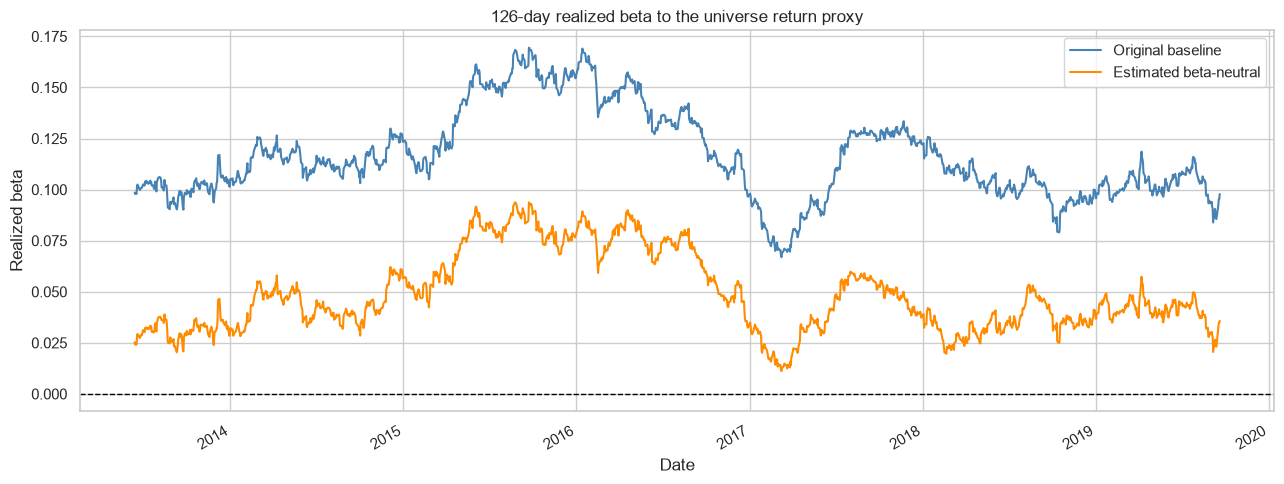

In [40]:
ROLLING_BETA_WINDOW = 126  # Approximately six trading months

rolling_proxy_variance = beta_test_proxy.rolling(
    ROLLING_BETA_WINDOW,
    min_periods=ROLLING_BETA_WINDOW,
).var()

rolling_realized_beta = pd.DataFrame({
    portfolio: (
        beta_gross_returns[portfolio]
        .rolling(
            ROLLING_BETA_WINDOW,
            min_periods=ROLLING_BETA_WINDOW,
        )
        .cov(beta_test_proxy)
        .div(
            rolling_proxy_variance.where(
                rolling_proxy_variance > 1e-12
            )
        )
    )
    for portfolio in beta_gross_returns.columns
})

fig, ax = plt.subplots(figsize=(13, 5))

colors = {
    "Original baseline": "steelblue",
    "Estimated beta-neutral": "darkorange",
}

for portfolio in rolling_realized_beta.columns:
    ax.plot(
        rolling_realized_beta.index.to_pydatetime(),
        rolling_realized_beta[portfolio].to_numpy(),
        label=portfolio,
        color=colors[portfolio],
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("126-day realized beta to the universe return proxy")
ax.set_ylabel("Realized beta")
ax.set_xlabel("Date")
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The beta adjustment substantially reduces realized exposure to the
universe return proxy. Full-period beta falls from 0.1152 to 0.0475,
while correlation decreases from 0.5357 to 0.2550.

The rolling estimates show that this reduction persists throughout
the displayed period. However, the adjusted portfolio retains positive
realized beta despite having zero estimated beta at construction.

The historical beta constraint therefore provides partial protection
against common market movements, rather than guaranteed realized
neutrality. Estimation error and changing relationships may contribute
to the remaining exposure; these diagnostics do not identify its cause.

Combined with the cost analysis, the adjustment reduces market exposure
but offers little improvement in net Sharpe at 5 bps.

## 5. Rolling Ridge alpha aggregation

We estimate alpha combination coefficients using Ridge regression.
To adapt to changing predictive relationships, the model is recalibrated
on the first available date of each calendar month using the latest
504 eligible daily observations.

Portfolio construction will maintain zero net dollar exposure, zero
estimated beta to the universe return proxy, and unit gross exposure.

The final comparison will use identical dates, risk constraints,
smoothing rules, and transaction costs for Ridge and equal weighting.

### 5.1 Monthly calibration schedule

Each calibration uses past observations only. We exclude the date
immediately preceding calibration, following the existing conservative
gap for assumed one-day forward returns.

Coefficients remain fixed until the next monthly calibration, while
daily alpha values continue to generate new stock scores.
The reserved validation period remains unused.

In [41]:
RIDGE_TRAINING_DAYS = 504
RIDGE_GAP_DAYS = 1

# Candidate penalties; selection will use research data only
RIDGE_PENALTIES = [0.01, 0.1, 1.0]

ridge_X = research_alphas.sort_index()
ridge_y = research_returns.reindex(ridge_X.index)

ridge_dates = (
    ridge_X.index.get_level_values("date")
    .unique()
    .sort_values()
)

# Start once the training window and gap are available
ridge_prediction_dates = ridge_dates[
    RIDGE_TRAINING_DAYS + RIDGE_GAP_DAYS:
]

In [42]:
monthly_dates = pd.Series(
    ridge_prediction_dates,
    index=ridge_prediction_dates,
)

ridge_schedule = []
schedule_rows = []

for month, date_group in monthly_dates.groupby(
    ridge_prediction_dates.to_period("M")
):
    prediction_dates = pd.DatetimeIndex(date_group.to_numpy())
    calibration_date = prediction_dates[0]

    calibration_position = ridge_dates.get_loc(calibration_date)

    # Exclusive slice endpoint: leaves one unused date before calibration
    train_stop = calibration_position - RIDGE_GAP_DAYS
    train_start = train_stop - RIDGE_TRAINING_DAYS
    training_dates = ridge_dates[train_start:train_stop]


    ridge_schedule.append({
        "calibration_date": calibration_date,
        "training_dates": training_dates,
        "prediction_dates": prediction_dates,
    })

    schedule_rows.append({
        "Calibration date": calibration_date,
        "Training start": training_dates.min(),
        "Training end": training_dates.max(),
        "Training dates": len(training_dates),
        "Prediction end": prediction_dates.max(),
        "Prediction dates": len(prediction_dates),
    })

ridge_schedule_summary = pd.DataFrame(schedule_rows)

print("Number of calibrations:", len(ridge_schedule_summary))
display(ridge_schedule_summary.head())
display(ridge_schedule_summary.tail())

Number of calibrations: 70


,Calibration date,Training start,Training end,Training dates,Prediction end,Prediction dates
0,2013-12-09,2012-01-02,2013-12-05,504,2013-12-31,17
1,2014-01-01,2012-01-25,2013-12-30,504,2014-01-31,23
2,2014-02-03,2012-02-27,2014-01-30,504,2014-02-28,20
3,2014-03-03,2012-03-26,2014-02-27,504,2014-03-31,21
4,2014-04-01,2012-04-24,2014-03-28,504,2014-04-30,22


,Calibration date,Training start,Training end,Training dates,Prediction end,Prediction dates
65,2019-05-01,2017-05-24,2019-04-29,504,2019-05-31,23
66,2019-06-03,2017-06-26,2019-05-30,504,2019-06-28,20
67,2019-07-01,2017-07-24,2019-06-27,504,2019-07-31,23
68,2019-08-01,2017-08-24,2019-07-30,504,2019-08-30,22
69,2019-09-02,2017-09-25,2019-08-29,504,2019-09-20,15


### 5.2 Fit monthly Ridge models

At each calibration date, Ridge learns how the 50 alphas jointly
predict cross-sectional relative returns over the preceding training
window.

Training targets are stock forward returns minus the same-date
universe average return. The alphas are already standardized.

We compare three regularization penalties using:

    mean squared error + lambda × sum of squared coefficients

Scikit-learn uses summed squared errors, so its alpha parameter equals
the number of training observations multiplied by lambda.

Each model predicts the subsequent monthly block without using that
block's returns during fitting.

In [43]:
# Relative returns: remove each date's average stock return
ridge_relative_y = ridge_y - ridge_y.groupby(
    level="date"
).transform("mean")

ridge_row_dates = ridge_X.index.get_level_values("date")

In [44]:
monthly_prediction_parts = []
monthly_coefficient_rows = []

for block_number, block in enumerate(ridge_schedule, start=1):
    training_mask = ridge_row_dates.isin(block["training_dates"])
    prediction_mask = ridge_row_dates.isin(block["prediction_dates"])

    X_train = ridge_X.loc[training_mask]
    y_train = ridge_relative_y.loc[training_mask]
    X_predict = ridge_X.loc[prediction_mask]

    block_predictions = pd.DataFrame(index=X_predict.index)

    for penalty in RIDGE_PENALTIES:
        model_name = f"Ridge lambda={penalty:g}"

        model = Ridge(
            alpha=len(X_train) * penalty,
            fit_intercept=False,
            solver="cholesky",
        )

        model.fit(X_train, y_train)
        block_predictions[model_name] = model.predict(X_predict)

        monthly_coefficient_rows.append({
            "Calibration date": block["calibration_date"],
            "Model": model_name,
            **dict(zip(ridge_X.columns, model.coef_)),
        })

    monthly_prediction_parts.append(block_predictions)

    if block_number == 1 or block_number % 12 == 0:
        print(
            f"Completed {block_number}/{len(ridge_schedule)} "
            f"monthly calibrations"
        )

ridge_monthly_predictions = pd.concat(
    monthly_prediction_parts
).sort_index()

ridge_monthly_coefficients = (
    pd.DataFrame(monthly_coefficient_rows)
    .set_index(["Calibration date", "Model"])
    .sort_index()
)

print("Monthly fitting completed.")

Completed 1/70 monthly calibrations
Completed 12/70 monthly calibrations
Completed 24/70 monthly calibrations
Completed 36/70 monthly calibrations
Completed 48/70 monthly calibrations
Completed 60/70 monthly calibrations
Monthly fitting completed.


In [45]:
expected_prediction_index = ridge_X.index[
    ridge_row_dates.isin(ridge_prediction_dates)
]

print(
    "Predicted dates:",
    ridge_monthly_predictions.index.get_level_values("date").nunique(),
)
print("Stock-date predictions per model:", len(ridge_monthly_predictions))

display(ridge_monthly_predictions.head())

# Coefficients from the latest monthly calibration
latest_calibration = ridge_monthly_coefficients.index.get_level_values(
    "Calibration date"
).max()

display(
    ridge_monthly_coefficients
    .xs(latest_calibration, level="Calibration date")
    .T
    .rename_axis("Alpha")
)

Predicted dates: 1510
Stock-date predictions per model: 755000


Ridge lambda=0.01  Ridge lambda=0.1  Ridge lambda=1
date       asset                                                     
2013-12-09 A000           -0.001439         -0.001044       -0.000489
           A001            0.000745          0.000470        0.000024
           A002           -0.000261         -0.000257       -0.000068
           A003            0.000341          0.000190        0.000159
           A004           -0.000843         -0.000633       -0.000171

Model,Ridge lambda=0.01,Ridge lambda=0.1,Ridge lambda=1
Alpha,,,
alpha_00,-4.328757e-07,-0.000001,0.000004
alpha_01,-6.240592e-04,-0.000162,-0.000006
alpha_02,5.209853e-04,0.000282,0.000067
alpha_03,-5.618061e-05,-0.000040,-0.000006
alpha_04,1.832321e-04,0.000164,0.000081
alpha_05,-6.253465e-05,-0.000051,-0.000006
alpha_06,-9.539342e-05,0.000005,0.000027
alpha_07,7.536438e-05,0.000068,0.000035
alpha_08,-8.226454e-05,-0.000072,-0.000026


### 5.3 Construct comparable risk-controlled portfolios

We convert each monthly Ridge model's daily predictions into stock
positions. Equal-weight alpha aggregation is included as the baseline.

Every portfolio uses the same dates and constraints:

- Zero net dollar exposure.
- Zero exposure to historically estimated stock market betas.
- Unit gross exposure, except when the adjusted signal is zero.

We initially apply no smoothing to isolate the aggregation method's
effect. The market-beta estimates use past returns only.

In [46]:
monthly_scores = ridge_monthly_predictions.copy()

monthly_scores["Equal weight"] = equal_weight_signal.reindex(
    monthly_scores.index
)

monthly_evaluation_dates = (
    monthly_scores.index.get_level_values("date")
    .unique()
    .sort_values()
)

monthly_assets = (
    monthly_scores.index.get_level_values("asset")
    .unique()
    .sort_values()
)

monthly_betas = estimated_betas.reindex(
    index=monthly_evaluation_dates,
    columns=monthly_assets,
)

In [47]:
def make_dollar_beta_neutral_weights(scores, betas):

    # Start with a signal whose cross-sectional mean is zero
    centered_scores = scores.sub(scores.mean(axis=1), axis=0)

    centered_betas = betas.sub(betas.mean(axis=1), axis=0)
    beta_squared_sum = centered_betas.pow(2).sum(axis=1)

    # Remove the signal component associated with estimated market beta
    adjustment = (
        centered_scores.mul(centered_betas).sum(axis=1)
        / beta_squared_sum.where(beta_squared_sum > 1e-12)
    ).fillna(0.0)

    residual_scores = centered_scores - centered_betas.mul(
        adjustment, axis=0
    )

    residual_scores = residual_scores.sub(
        residual_scores.mean(axis=1),
        axis=0,
    )

    gross = residual_scores.abs().sum(axis=1)

    target_weights = residual_scores.div(
        gross.where(gross > 1e-12),
        axis=0,
    ).fillna(0.0)

    return target_weights


monthly_strategy_weights = {}

for strategy in monthly_scores.columns:
    score_matrix = monthly_scores[strategy].unstack("asset").reindex(
        index=monthly_evaluation_dates,
        columns=monthly_assets,
    )

    monthly_strategy_weights[strategy] = (
        make_dollar_beta_neutral_weights(score_matrix, monthly_betas)
    )

In [48]:
monthly_exposure_rows = []

for strategy, target in monthly_strategy_weights.items():
    net_exposure = target.sum(axis=1)
    gross_exposure = target.abs().sum(axis=1)
    estimated_beta = target.mul(monthly_betas).sum(axis=1)

    assert np.isfinite(target.to_numpy()).all()
    np.testing.assert_allclose(net_exposure, 0, atol=1e-10)
    np.testing.assert_allclose(estimated_beta, 0, atol=1e-10)

    assert np.all(
        np.isclose(gross_exposure, 1.0)
        | np.isclose(gross_exposure, 0.0)
    )

    monthly_exposure_rows.append({
        "Strategy": strategy,
        "Maximum absolute net exposure": net_exposure.abs().max(),
        "Average gross exposure": gross_exposure.mean(),
        "Maximum absolute estimated beta": estimated_beta.abs().max(),
        "Largest absolute stock weight (%)": (
            target.abs().to_numpy().max() * 100
        ),
    })

monthly_exposure_summary = (
    pd.DataFrame(monthly_exposure_rows).set_index("Strategy")
)

display(monthly_exposure_summary)

,Maximum absolute net exposure,Average gross exposure,Maximum absolute estimated beta,Largest absolute stock weight (%)
Strategy,,,,
Ridge lambda=0.01,1.717376e-16,1.0,2.549230e-16,1.211288
Ridge lambda=0.1,2.168404e-16,1.0,2.016616e-16,1.235505
Ridge lambda=1,2.280348e-16,1.0,2.675811e-16,1.349539
Equal weight,1.864828e-16,1.0,3.593046e-16,1.199426


### 5.4 Backtest monthly Ridge against equal weighting

We compare the three Ridge penalties with equal-weight alpha aggregation
on identical research dates.

All portfolios are dollar-neutral, neutral to estimated market beta,
and scaled to unit gross exposure. No smoothing is applied.

Positions carry continuously across monthly calibrations, so changes
in model coefficients incur trading costs. Portfolios start from cash,
initial entry is charged, and terminal liquidation is excluded.

In [49]:
monthly_asset_returns = df_asset.reindex(
    index=monthly_evaluation_dates,
    columns=monthly_assets,
)

# Ensure consecutive dates for the position-drift calculation
monthly_date_positions = df_asset.index.sort_values().get_indexer(
    monthly_evaluation_dates
)


print(
    "Evaluation period:",
    monthly_evaluation_dates.min().date(),
    "to",
    monthly_evaluation_dates.max().date(),
)
print("Evaluation dates:", len(monthly_evaluation_dates))

Evaluation period: 2013-12-09 to 2019-09-20
Evaluation dates: 1510


In [50]:
ANNUALIZATION = 252
MONTHLY_COST_SCENARIOS = [0, 1, 2, 5]

monthly_backtests = {}
monthly_performance_rows = []

for strategy, target_weights in monthly_strategy_weights.items():
    for cost_bps in MONTHLY_COST_SCENARIOS:
        backtest = backtest_beta_portfolio(
            target_weights,
            monthly_asset_returns,
            cost_bps,
        )

        monthly_backtests[(strategy, cost_bps)] = backtest

        metrics = summarize_portfolio(
            backtest["Net return"]
        ).to_dict()

        metrics.update({
            "Strategy": strategy,
            "Cost (bps)": cost_bps,
            "Average daily traded weight (%)": (
                backtest["Traded weight"].mean() * 100
            ),
        })

        monthly_performance_rows.append(metrics)

monthly_performance = (
    pd.DataFrame(monthly_performance_rows)
    .set_index(["Strategy", "Cost (bps)"])
)

display(monthly_performance.round(4))

Annualized Sharpe  Annualized Sortino  \
Strategy          Cost (bps)                                          
Ridge lambda=0.01 0                     15.9514             51.1232   
                  1                     15.3114             47.2802   
                  2                     14.6715             43.6603   
                  5                     12.7521             34.0206   
Ridge lambda=0.1  0                     13.9783             43.9680   
                  1                     13.2744             39.9013   
                  2                     12.5702             36.1254   
                  5                     10.4568             26.3412   
Ridge lambda=1    0                     11.6950             32.4436   
                  1                     10.9763             29.0798   
                  2                     10.2573             25.9677   
                  5                      8.0987             17.9582   
Equal weight      0                      5.9190             11.8063   
                  1                      5.0511              9.5740   
                  2                      4.1830              7.5417   
                  5                      1.5781              2.4631   

                              Total return (%)  Maximum drawdown (%)  \
Strategy          Cost (bps)                                           
Ridge lambda=0.01 0                   330.6293                5.2344   
                  1                   306.2069                5.6241   
                  2                   283.1679                6.0122   
                  5                   221.5900                7.1672   
Ridge lambda=0.1  0                   223.1140                0.3614   
                  1                   204.5621                0.3884   
                  2                   187.0740                0.4274   
                  5                   140.4008                0.5949   
Ridge lambda=1    0                   168.9638                0.6001   
                  1                   153.0654                0.6318   
                  2                   138.1055                0.6636   
                  5                    98.3202                0.8162   
Equal weight      0                    65.2226                1.0656   
                  1                    53.4802                1.1558   
                  2                    42.5712                1.2762   
                  5                    14.2751                2.3997   

                              Average daily traded weight (%)  
Strategy          Cost (bps)                                   
Ridge lambda=0.01 0                                   38.7013  
                  1                                   38.7021  
                  2                                   38.7028  
                  5                                   38.7050  
Ridge lambda=0.1  0                                   39.1881  
                  1                                   39.1888  
                  2                                   39.1896  
                  5                                   39.1919  
Ridge lambda=1    0                                   40.3752  
                  1                                   40.3760  
                  2                                   40.3768  
                  5                                   40.3792  
Equal weight      0                                   48.8367  
                  1                                   48.8379  
                  2                                   48.8391  
                  5                                   48.8427

In [51]:
COMPARISON_COST_BPS = 5

print("Overall results at 5 bps:")
display(
    monthly_performance
    .xs(COMPARISON_COST_BPS, level="Cost (bps)")
    .round(4)
)

yearly_performance_rows = []

for strategy in monthly_strategy_weights:
    net_returns_series = monthly_backtests[
        (strategy, COMPARISON_COST_BPS)
    ]["Net return"]

    for year, year_returns in net_returns_series.groupby(
        net_returns_series.index.year
    ):
        metrics = summarize_portfolio(year_returns).to_dict()

        metrics.update({
            "Strategy": strategy,
            "Year": year,
            "Observations": len(year_returns),
        })

        yearly_performance_rows.append(metrics)

monthly_yearly_performance = (
    pd.DataFrame(yearly_performance_rows)
    .set_index(["Strategy", "Year"])
)

print("Net Sharpe by year at 5 bps:")
display(
    monthly_yearly_performance["Annualized Sharpe"]
    .unstack("Year")
    .round(3)
)

print("Observations per year:")
display(
    monthly_yearly_performance["Observations"]
    .unstack("Year")
)

Overall results at 5 bps:


,Annualized Sharpe,Annualized Sortino,Total return (%),Maximum drawdown (%),Average daily traded weight (%)
Strategy,,,,,
Ridge lambda=0.01,12.7521,34.0206,221.5900,7.1672,38.7050
Ridge lambda=0.1,10.4568,26.3412,140.4008,0.5949,39.1919
Ridge lambda=1,8.0987,17.9582,98.3202,0.8162,40.3792
Equal weight,1.5781,2.4631,14.2751,2.3997,48.8427


Net Sharpe by year at 5 bps:


Year,2013,2014,2015,2016,2017,2018,2019
Strategy,,,,,,,
Equal weight,2.025,4.245,2.167,0.218,0.875,-0.232,2.416
Ridge lambda=0.01,11.041,18.278,19.695,20.147,6.563,7.234,11.081
Ridge lambda=0.1,10.635,16.356,13.456,12.142,8.557,6.309,6.630
Ridge lambda=1,8.570,14.376,10.086,7.591,7.720,4.599,4.298


Observations per year:


Year,2013,2014,2015,2016,2017,2018,2019
Strategy,,,,,,,
Equal weight,17,261,261,261,260,261,189
Ridge lambda=0.01,17,261,261,261,260,261,189
Ridge lambda=0.1,17,261,261,261,260,261,189
Ridge lambda=1,17,261,261,261,260,261,189


### 5.5 Visual comparison of performance and stability

We compare cumulative equity, drawdown, rolling Sharpe, and trading
activity at 5 bps per unit traded.

All strategies use identical dates and portfolio constraints.
Rolling statistics help identify whether full-period results hide
extended periods of weak performance.

In [52]:
PLOT_COST_BPS = 5
SHARPE_WINDOW = 126
TURNOVER_WINDOW = 63

monthly_net_returns = pd.DataFrame({
    strategy: monthly_backtests[
        (strategy, PLOT_COST_BPS)
    ]["Net return"]
    for strategy in monthly_strategy_weights
})

monthly_traded_weight = pd.DataFrame({
    strategy: monthly_backtests[
        (strategy, PLOT_COST_BPS)
    ]["Traded weight"]
    for strategy in monthly_strategy_weights
})

monthly_equity = (1 + monthly_net_returns).cumprod()

monthly_drawdown = (
    monthly_equity
    / monthly_equity.cummax().clip(lower=1.0)
    - 1
) * 100

rolling_mean = monthly_net_returns.rolling(
    SHARPE_WINDOW,
    min_periods=SHARPE_WINDOW,
).mean()

rolling_std = monthly_net_returns.rolling(
    SHARPE_WINDOW,
    min_periods=SHARPE_WINDOW,
).std()

monthly_rolling_sharpe = (
    np.sqrt(252) * rolling_mean / rolling_std.replace(0, np.nan)
)

monthly_rolling_turnover = monthly_traded_weight.rolling(
    TURNOVER_WINDOW,
    min_periods=TURNOVER_WINDOW,
).mean() * 100

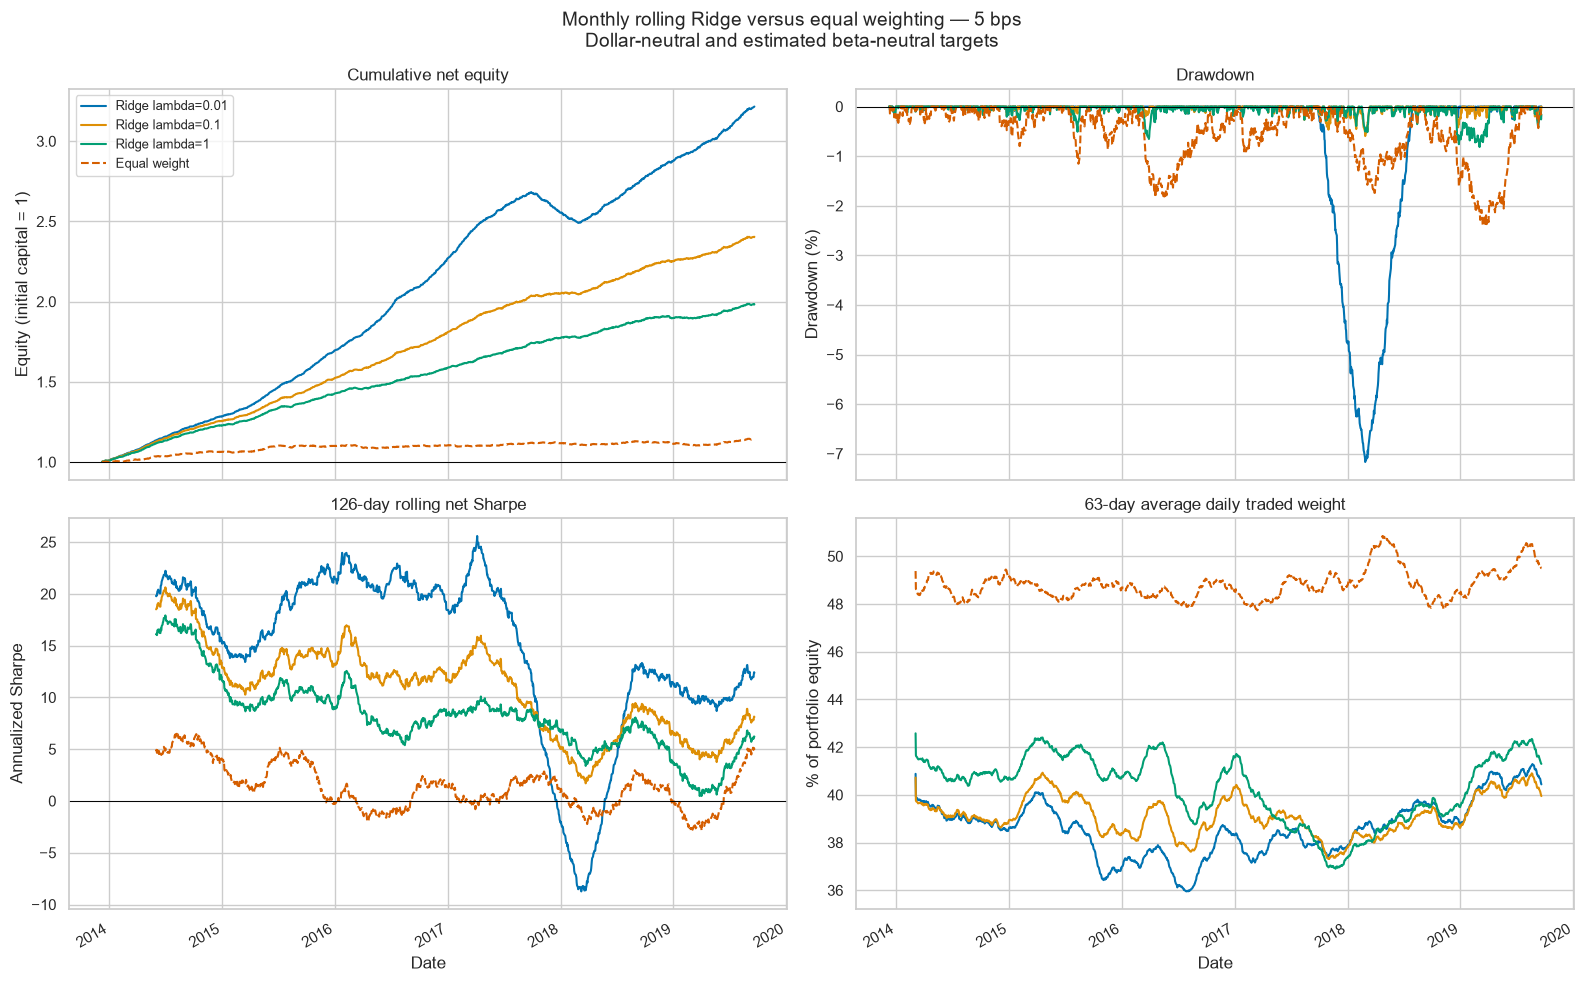

In [53]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    sharex=True,
)

strategies = monthly_net_returns.columns
palette = sns.color_palette("colorblind", n_colors=len(strategies))
strategy_colors = dict(zip(strategies, palette))

plot_dates = monthly_net_returns.index.to_pydatetime()

panels = [
    (
        axes[0, 0],
        monthly_equity,
        "Cumulative net equity",
        "Equity (initial capital = 1)",
    ),
    (
        axes[0, 1],
        monthly_drawdown,
        "Drawdown",
        "Drawdown (%)",
    ),
    (
        axes[1, 0],
        monthly_rolling_sharpe,
        "126-day rolling net Sharpe",
        "Annualized Sharpe",
    ),
    (
        axes[1, 1],
        monthly_rolling_turnover,
        "63-day average daily traded weight",
        "% of portfolio equity",
    ),
]

for ax, series_table, title, ylabel in panels:
    for strategy in strategies:
        ax.plot(
            plot_dates,
            series_table[strategy].to_numpy(),
            label=strategy,
            color=strategy_colors[strategy],
            linewidth=1.5,
            linestyle="--" if strategy == "Equal weight" else "-",
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)

axes[0, 0].legend(fontsize=9)
axes[0, 0].axhline(1, color="black", linewidth=0.7)
axes[0, 1].axhline(0, color="black", linewidth=0.7)
axes[1, 0].axhline(0, color="black", linewidth=0.7)

for ax in axes[1]:
    ax.set_xlabel("Date")

fig.suptitle(
    "Monthly rolling Ridge versus equal weighting — 5 bps\n"
    "Dollar-neutral and estimated beta-neutral targets",
    fontsize=14,
)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Monthly rolling Ridge substantially outperforms equal-weight aggregation
under identical exposure constraints and trading-cost assumptions.

Lambda=0.01 achieves the highest overall net Sharpe and cumulative
return, but experiences a maximum drawdown of 7.17% and a period of
negative rolling Sharpe around early 2018. Its positive annual results
therefore conceal a substantial period of deterioration.

Lambda=0.1 offers a more balanced research-period profile: net Sharpe
of 10.46, maximum drawdown of 0.59%, and positive rolling Sharpe
throughout the displayed windows. Its trading activity is only slightly
higher than that of lambda=0.01.

We provisionally prefer lambda=0.1 when drawdown control and temporal
consistency accompany the net-Sharpe objective. This is a risk-based
selection rather than selection of the highest-Sharpe model.
Its performance still requires assessment beyond the research period.

### 5.6 Smoothing the selected Ridge portfolio

#### 5.6.1 Construct smoothed portfolios

We keep monthly Ridge calibration, the 504-date training window, and
lambda=0.1 fixed. We compare no smoothing with half-lives of one and
three dates, applying the same procedure to equal-weight aggregation.

We first convert daily scores into dollar-neutral, unit-gross targets.
This makes smoothing less sensitive to changes in prediction scale
between monthly model refits.

We smooth these targets using current and past values only, then impose
zero estimated market beta and restore unit gross exposure.

Smoothing continues across monthly refits without resetting.

In [54]:
SMOOTHING_STRATEGIES = [
    "Ridge lambda=0.1",
    "Equal weight",
]

SMOOTHING_SETTINGS = {
    "No smoothing": None,
    "1-day": 1,
    "3-day": 3,
}

monthly_smoothed_weights = {}

In [55]:
for strategy in SMOOTHING_STRATEGIES:
    scores = monthly_scores[strategy].unstack("asset").reindex(
        index=monthly_evaluation_dates,
        columns=monthly_assets,
    )

    # Comparable target scale before smoothing
    centered_scores = scores.sub(scores.mean(axis=1), axis=0)
    gross_scores = centered_scores.abs().sum(axis=1)

    base_targets = centered_scores.div(
        gross_scores.where(gross_scores > 1e-12),
        axis=0,
    ).fillna(0.0)

    for smoothing_name, half_life in SMOOTHING_SETTINGS.items():
        if half_life is None:
            smoothed_targets = base_targets.copy()
        else:
            smoothed_targets = base_targets.ewm(
                halflife=half_life,
                adjust=False,
            ).mean()

        # Apply today's beta constraint AFTER smoothing
        final_targets = make_dollar_beta_neutral_weights(
            smoothed_targets,
            monthly_betas,
        )

        monthly_smoothed_weights[
            (strategy, smoothing_name)
        ] = final_targets

In [56]:
smoothing_exposure_rows = []

for (strategy, smoothing_name), target in (
    monthly_smoothed_weights.items()
):
    net_exposure = target.sum(axis=1)
    gross_exposure = target.abs().sum(axis=1)
    estimated_beta = target.mul(monthly_betas).sum(axis=1)

    np.testing.assert_allclose(net_exposure, 0, atol=1e-10)
    np.testing.assert_allclose(estimated_beta, 0, atol=1e-10)

    # Confirm that no smoothing reproduces section 5.3
    if smoothing_name == "No smoothing":
        np.testing.assert_allclose(
            target.to_numpy(),
            monthly_strategy_weights[strategy].to_numpy(),
            atol=1e-10,
            rtol=1e-8,
        )

    smoothing_exposure_rows.append({
        "Strategy": strategy,
        "Smoothing": smoothing_name,
        "Maximum absolute net exposure": net_exposure.abs().max(),
        "Average gross exposure": gross_exposure.mean(),
        "Maximum absolute estimated beta": estimated_beta.abs().max(),
        "Largest absolute stock weight (%)": (
            target.abs().to_numpy().max() * 100
        ),
    })

smoothing_exposure_summary = (
    pd.DataFrame(smoothing_exposure_rows)
    .set_index(["Strategy", "Smoothing"])
)

display(smoothing_exposure_summary)

Maximum absolute net exposure  \
Strategy         Smoothing                                     
Ridge lambda=0.1 No smoothing                   1.942890e-16   
                 1-day                          1.873501e-16   
                 3-day                          1.704366e-16   
Equal weight     No smoothing                   2.717688e-16   
                 1-day                          1.836638e-16   
                 3-day                          1.665335e-16   

                               Average gross exposure  \
Strategy         Smoothing                              
Ridge lambda=0.1 No smoothing                     1.0   
                 1-day                            1.0   
                 3-day                            1.0   
Equal weight     No smoothing                     1.0   
                 1-day                            1.0   
                 3-day                            1.0   

                               Maximum absolute estimated beta  \
Strategy         Smoothing                                       
Ridge lambda=0.1 No smoothing                     2.233456e-16   
                 1-day                            2.218278e-16   
                 3-day                            2.376571e-16   
Equal weight     No smoothing                     3.597654e-16   
                 1-day                            4.270130e-16   
                 3-day                            4.407553e-16   

                               Largest absolute stock weight (%)  
Strategy         Smoothing                                        
Ridge lambda=0.1 No smoothing                           1.235505  
                 1-day                                  1.196462  
                 3-day                                  1.204173  
Equal weight     No smoothing                           1.199426  
                 1-day                                  1.178437  
                 3-day                                  1.139271

#### 5.6.2 Evaluate smoothing after trading costs

We backtest all six portfolios continuously, including across monthly
model recalibrations.

Each portfolio starts from cash. Transaction costs apply to initial
entry and subsequent trading, including adjustments for position drift.
No terminal liquidation is charged.

We compare net performance and turnover at 0, 1, 2, and 5 basis points
per unit traded.

In [57]:
ANNUALIZATION = 252
SMOOTHING_COST_SCENARIOS = [0, 1, 2, 5]

monthly_smoothing_backtests = {}
monthly_smoothing_rows = []

for (strategy, smoothing_name), target_weights in (
    monthly_smoothed_weights.items()
):
    for cost_bps in SMOOTHING_COST_SCENARIOS:
        backtest = backtest_beta_portfolio(
            target_weights,
            monthly_asset_returns,
            cost_bps,
        )

        monthly_smoothing_backtests[
            (strategy, smoothing_name, cost_bps)
        ] = backtest

        metrics = summarize_portfolio(
            backtest["Net return"]
        ).to_dict()

        metrics.update({
            "Strategy": strategy,
            "Smoothing": smoothing_name,
            "Cost (bps)": cost_bps,
            "Average daily traded weight (%)": (
                backtest["Traded weight"].mean() * 100
            ),
        })

        monthly_smoothing_rows.append(metrics)

        # No smoothing should reproduce the previous backtest
        if smoothing_name == "No smoothing":
            np.testing.assert_allclose(
                backtest["Net return"].to_numpy(),
                monthly_backtests[
                    (strategy, cost_bps)
                ]["Net return"].to_numpy(),
                atol=1e-12,
                rtol=1e-8,
            )

monthly_smoothing_performance = (
    pd.DataFrame(monthly_smoothing_rows)
    .set_index(["Strategy", "Smoothing", "Cost (bps)"])
)

display(monthly_smoothing_performance.round(4))

Annualized Sharpe  \
Strategy         Smoothing    Cost (bps)                      
Ridge lambda=0.1 No smoothing 0                     13.9783   
                              1                     13.2744   
                              2                     12.5702   
                              5                     10.4568   
                 1-day        0                     13.5740   
                              1                     13.1622   
                              2                     12.7503   
                              5                     11.5137   
                 3-day        0                     11.4202   
                              1                     11.1764   
                              2                     10.9324   
                              5                     10.1998   
Equal weight     No smoothing 0                      5.9190   
                              1                      5.0511   
                              2                      4.1830   
                              5                      1.5781   
                 1-day        0                      5.6750   
                              1                      5.1869   
                              2                      4.6987   
                              5                      3.2337   
                 3-day        0                      4.7937   
                              1                      4.5237   
                              2                      4.2535   
                              5                      3.4429   

                                          Annualized Sortino  \
Strategy         Smoothing    Cost (bps)                       
Ridge lambda=0.1 No smoothing 0                      43.9680   
                              1                      39.9013   
                              2                      36.1254   
                              5                      26.3412   
                 1-day        0                      41.4866   
                              1                      39.1835   
                              2                      36.9786   
                              5                      30.9097   
                 3-day        0                      30.3481   
                              1                      29.2582   
                              2                      28.1955   
                              5                      25.1647   
Equal weight     No smoothing 0                      11.8063   
                              1                       9.5740   
                              2                       7.5417   
                              5                       2.4631   
                 1-day        0                      11.0835   
                              1                       9.8448   
                              2                       8.6698   
                              5                       5.4920   
                 3-day        0                       8.7946   
                              1                       8.1739   
                              2                       7.5705   
                              5                       5.8593   

                                          Total return (%)  \
Strategy         Smoothing    Cost (bps)                     
Ridge lambda=0.1 No smoothing 0                   223.1140   
                              1                   204.5621   
                              2                   187.0740   
                              5                   140.4008   
                 1-day        0                   209.4506   
                              1                   199.0009   
                              2                   188.9036   
                              5                   160.6095   
                 3-day        0                   154.7824   
                              1                   149.72

In [58]:
SMOOTHING_COMPARISON_COST = 5

monthly_smoothing_at_cost = monthly_smoothing_performance.xs(
    SMOOTHING_COMPARISON_COST,
    level="Cost (bps)",
)

display(monthly_smoothing_at_cost.round(4))

Annualized Sharpe  Annualized Sortino  \
Strategy         Smoothing                                             
Ridge lambda=0.1 No smoothing            10.4568             26.3412   
                 1-day                   11.5137             30.9097   
                 3-day                   10.1998             25.1647   
Equal weight     No smoothing             1.5781              2.4631   
                 1-day                    3.2337              5.4920   
                 3-day                    3.4429              5.8593   

                               Total return (%)  Maximum drawdown (%)  \
Strategy         Smoothing                                              
Ridge lambda=0.1 No smoothing          140.4008                0.5949   
                 1-day                 160.6095                0.5100   
                 3-day                 130.4904                0.7726   
Equal weight     No smoothing           14.2751                2.3997   
                 1-day                  31.8515                1.4177   
                 3-day                  34.6106                1.4945   

                               Average daily traded weight (%)  
Strategy         Smoothing                                      
Ridge lambda=0.1 No smoothing                          39.1919  
                 1-day                                 22.7675  
                 3-day                                 13.2794  
Equal weight     No smoothing                          48.8427  
                 1-day                                 27.7270  
                 3-day                                 15.4837

In [59]:
monthly_smoothing_sharpe = (
    monthly_smoothing_performance["Annualized Sharpe"]
    .unstack("Cost (bps)")
)

display(monthly_smoothing_sharpe.round(3))

Cost (bps)                          0       1       2       5
Strategy         Smoothing                                   
Equal weight     1-day          5.675   5.187   4.699   3.234
                 3-day          4.794   4.524   4.254   3.443
                 No smoothing   5.919   5.051   4.183   1.578
Ridge lambda=0.1 1-day         13.574  13.162  12.750  11.514
                 3-day         11.420  11.176  10.932  10.200
                 No smoothing  13.978  13.274  12.570  10.457

#### 5.6.3 Check stability and realized market exposure

We compare equity, drawdown, rolling net Sharpe, and trading activity
at 5 bps per unit traded.

We also measure realized beta and correlation against the universe
return proxy. Estimated beta neutrality at construction does not
guarantee zero realized market exposure.

In [60]:
PLOT_COST_BPS = 5

smoothing_net_returns = pd.DataFrame({
    f"{strategy} | {smoothing}": monthly_smoothing_backtests[
        (strategy, smoothing, PLOT_COST_BPS)
    ]["Net return"]
    for strategy, smoothing in monthly_smoothed_weights
})

smoothing_traded_weight = pd.DataFrame({
    f"{strategy} | {smoothing}": monthly_smoothing_backtests[
        (strategy, smoothing, PLOT_COST_BPS)
    ]["Traded weight"]
    for strategy, smoothing in monthly_smoothed_weights
})

smoothing_equity = (1 + smoothing_net_returns).cumprod()

smoothing_drawdown = (
    smoothing_equity
    / smoothing_equity.cummax().clip(lower=1.0)
    - 1
) * 100

smoothing_rolling_sharpe = (
    np.sqrt(252)
    * smoothing_net_returns.rolling(126, min_periods=126).mean()
    / smoothing_net_returns.rolling(
        126, min_periods=126
    ).std().replace(0, np.nan)
)

smoothing_rolling_turnover = (
    smoothing_traded_weight
    .rolling(63, min_periods=63)
    .mean() * 100
)

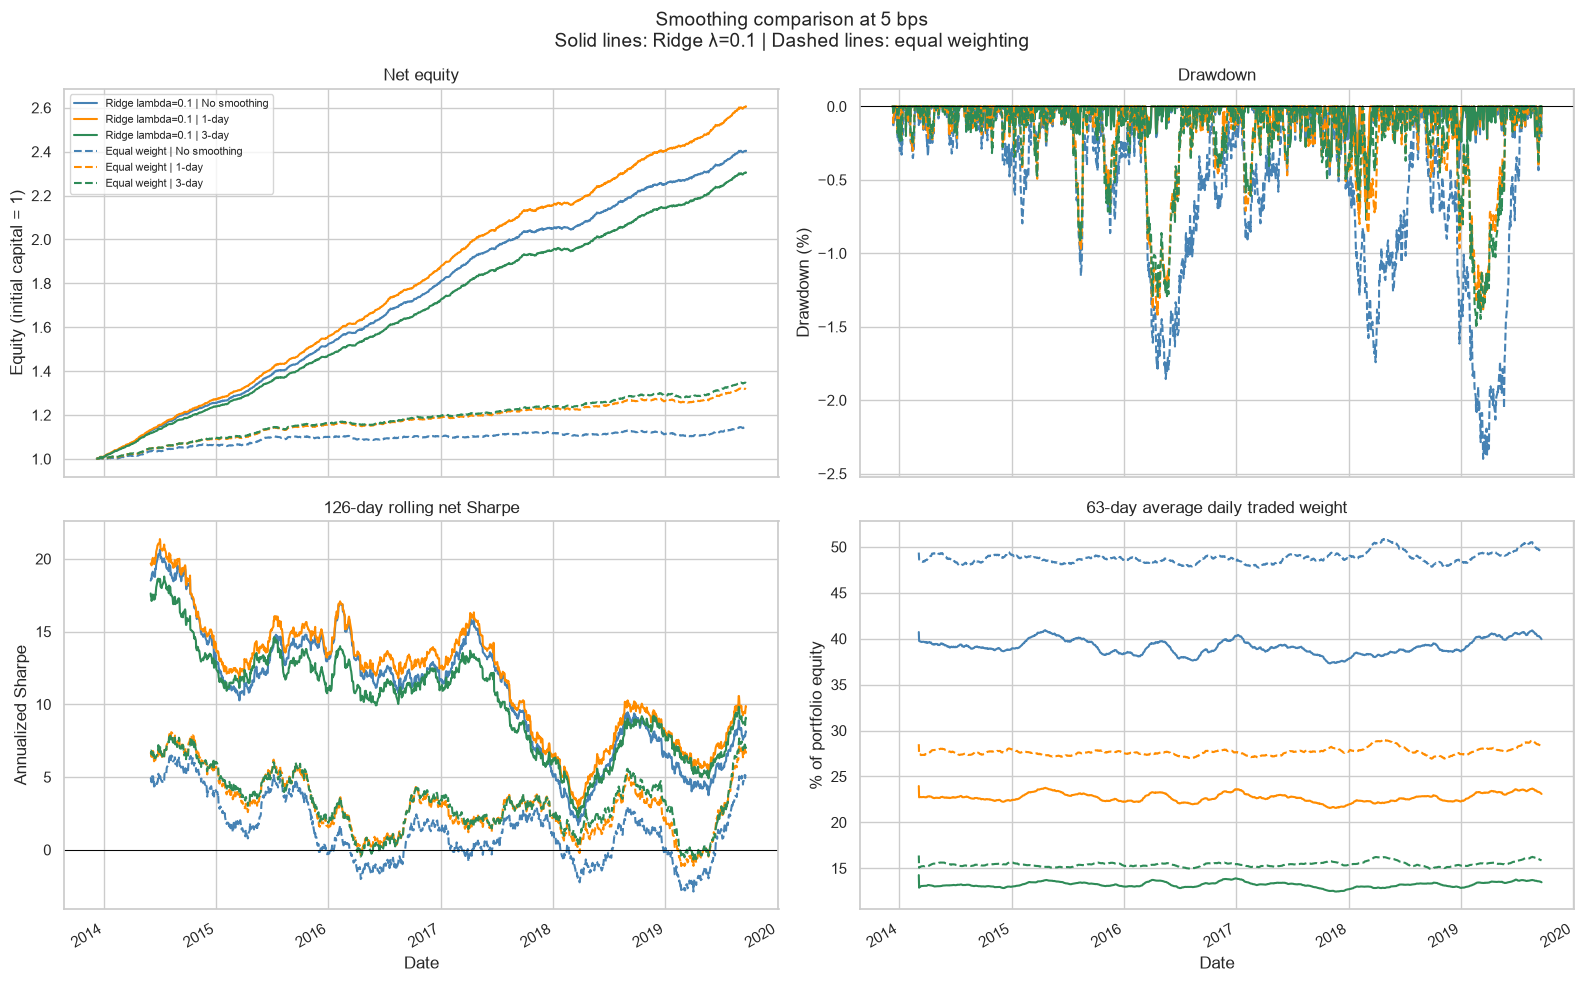

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

smoothing_colors = {
    "No smoothing": "steelblue",
    "1-day": "darkorange",
    "3-day": "seagreen",
}

panels = [
    (axes[0, 0], smoothing_equity,
     "Net equity", "Equity (initial capital = 1)"),

    (axes[0, 1], smoothing_drawdown,
     "Drawdown", "Drawdown (%)"),

    (axes[1, 0], smoothing_rolling_sharpe,
     "126-day rolling net Sharpe", "Annualized Sharpe"),

    (axes[1, 1], smoothing_rolling_turnover,
     "63-day average daily traded weight", "% of portfolio equity"),
]

for strategy, smoothing in monthly_smoothed_weights:
    label = f"{strategy} | {smoothing}"

    for ax, series_table, title, ylabel in panels:
        ax.plot(
            series_table.index.to_pydatetime(),
            series_table[label].to_numpy(),
            label=label,
            color=smoothing_colors[smoothing],
            linestyle="--" if strategy == "Equal weight" else "-",
            linewidth=1.5,
        )

for ax, _, title, ylabel in panels:
    ax.set_title(title)
    ax.set_ylabel(ylabel)

axes[0, 0].legend(fontsize=8)
axes[0, 1].axhline(0, color="black", linewidth=0.7)
axes[1, 0].axhline(0, color="black", linewidth=0.7)

for ax in axes[1]:
    ax.set_xlabel("Date")

fig.suptitle(
    "Smoothing comparison at 5 bps\n"
    "Solid lines: Ridge λ=0.1 | Dashed lines: equal weighting",
    fontsize=14,
)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [62]:
smoothing_market_proxy = monthly_asset_returns.mean(axis=1)
proxy_variance = smoothing_market_proxy.var()

assert proxy_variance > 0

smoothing_exposure_rows = []

for strategy, smoothing in monthly_smoothed_weights:
    gross_returns_series = monthly_smoothing_backtests[
        (strategy, smoothing, 0)
    ]["Gross return"]

    assert gross_returns_series.index.equals(smoothing_market_proxy.index)

    smoothing_exposure_rows.append({
        "Strategy": strategy,
        "Smoothing": smoothing,
        "Realized beta": (
            gross_returns_series.cov(smoothing_market_proxy)
            / proxy_variance
        ),
        "Correlation with proxy": (
            gross_returns_series.corr(smoothing_market_proxy)
        ),
    })

smoothing_realized_exposure = (
    pd.DataFrame(smoothing_exposure_rows)
    .set_index(["Strategy", "Smoothing"])
)

display(smoothing_realized_exposure.round(4))

Realized beta  Correlation with proxy
Strategy         Smoothing                                          
Ridge lambda=0.1 No smoothing         0.0155                  0.0840
                 1-day                0.0150                  0.0818
                 3-day                0.0139                  0.0770
Equal weight     No smoothing         0.0496                  0.2657
                 1-day                0.0498                  0.2642
                 3-day                0.0530                  0.2790

One-day smoothing provides the strongest net performance among the
tested Ridge smoothing settings at 5 bps. It increases Sharpe from
10.46 to 11.51 and reduces maximum drawdown from 0.595% to 0.510%.
Average daily traded weight falls from 39.19% to 22.77%, a reduction
of approximately 42%.

Three-day smoothing reduces trading further but lowers net Sharpe and
increases maximum drawdown relative to one-day smoothing. Its additional
cost savings do not compensate for the loss of responsiveness.

The rolling plots show that Ridge performance varies over time,
particularly around 2018, while remaining positive across the displayed
126-day windows. The one-day version substantially outperforms the
equally smoothed baseline, whose net Sharpe is 3.23.

Realized beta remains small at 0.0150, with correlation of 0.0818 to
the universe proxy. The improvement therefore does not coincide with
an increase in measured market exposure.

We provisionally retain monthly rolling Ridge with lambda=0.1 and
one-day smoothing. This choice depends on the assumed trading costs:
without costs or at 1 bp, the unsmoothed Ridge has slightly higher
Sharpe. These remain research-period selection results.

## 6. Fixed-model assessment on the later period

### 6.1 Configuration and initialization rules

We retain monthly rolling Ridge with lambda=0.1, a 504-date training
window, and one-day smoothing.

The training target remains each stock's forward return minus the
same-date universe average return. Estimated beta neutrality is imposed
during portfolio construction, after smoothing.

Stock betas use 252 historical observations with the existing two-row
delay under the one-day forward-return assumption.

Both Ridge and equal weighting start from cash on the first assessment
date. Each strategy initializes smoothing with its first daily target.
Smoothing and positions then continue across monthly model updates.

Ridge is calibrated on the first assessment date and subsequently on
the first available date of each calendar month. Earlier assessment
outcomes may enter subsequent training windows once eligible.

The primary comparison uses 5 bps per unit traded, with 0, 1, and 2 bps
as sensitivity scenarios. Initial entry is charged; terminal liquidation,
borrowing costs, and financing costs are excluded.

These dates were examined during earlier research. Results are therefore
a later-period assessment, not a new independent validation.

In [63]:
ASSESSMENT_CONFIG = {
    "ridge_lambda": 0.1,
    "training_window_dates": 504,
    "training_gap_dates": 1,
    "calibration_frequency": "calendar month",
    "training_target": "cross-sectional relative returns",
    "smoothing_halflife_dates": 1,
    "beta_window_dates": 252,
    "beta_return_lag_dates": 2,
    "target_net_exposure": 0.0,
    "target_estimated_beta": 0.0,
    "target_gross_exposure": 1.0,
    "primary_cost_bps": 5,
    "cost_scenarios_bps": [0, 1, 2, 5],
    "initial_positions": "cash",
    "smoothing_initialization": "first daily target",
}

display(
    pd.Series(
        ASSESSMENT_CONFIG,
        name="Chosen setting",
    ).to_frame()
)

,Chosen setting
ridge_lambda,0.1
training_window_dates,504
training_gap_dates,1
calibration_frequency,calendar month
training_target,cross-sectional relative returns
smoothing_halflife_dates,1
beta_window_dates,252
beta_return_lag_dates,2
target_net_exposure,0.0
target_estimated_beta,0.0


In [65]:
assessment_dates = pd.DatetimeIndex(
    validation_dates
).sort_values()

available_dates = df_asset.index.sort_values()

research_date_index = (
    research_alphas.index.get_level_values("date")
    .unique()
    .sort_values()
)

assert assessment_dates.is_unique
assert len(assessment_dates) == 504
assert research_date_index.intersection(assessment_dates).empty
assert research_date_index.max() < assessment_dates.min()

first_assessment_date = assessment_dates[0]
first_position = available_dates.get_loc(first_assessment_date)

training_stop = (
    first_position - ASSESSMENT_CONFIG["training_gap_dates"]
)
training_start = (
    training_stop - ASSESSMENT_CONFIG["training_window_dates"]
)

assert training_start >= 0

first_training_dates = available_dates[
    training_start:training_stop
]

assert len(first_training_dates) == 504
assert first_training_dates.max() < first_assessment_date

boundary_summary = pd.Series({
    "Assessment start": assessment_dates.min(),
    "Assessment end": assessment_dates.max(),
    "Assessment observations": len(assessment_dates),
    "First training start": first_training_dates.min(),
    "First training end": first_training_dates.max(),
    "First training observations": len(first_training_dates),
})

display(boundary_summary.to_frame("Period information"))

,Period information
Assessment start,2019-09-24 00:00:00
Assessment end,2021-08-27 00:00:00
Assessment observations,504
First training start,2017-10-17 00:00:00
First training end,2019-09-20 00:00:00
First training observations,504


### 6.2 Generate chronological assessment predictions

We calibrate Ridge on the first assessment date and then on the first
available date of each calendar month.

Every calibration uses the latest 504 eligible dates, excluding the
date immediately preceding calibration. Model coefficients remain
fixed throughout each prediction block.

No outcome from the current prediction block enters that block's
training. Earlier assessment outcomes may enter later calibrations,
following the predetermined rolling update rule.

In [66]:
assessment_schedule = []
assessment_schedule_rows = []

assessment_months = pd.Series(
    assessment_dates,
    index=assessment_dates,
)

for month, date_group in assessment_months.groupby(
    assessment_dates.to_period("M")
):
    prediction_dates = pd.DatetimeIndex(date_group.to_numpy())
    calibration_date = prediction_dates[0]

    calibration_position = available_dates.get_loc(calibration_date)

    train_stop = (
        calibration_position
        - ASSESSMENT_CONFIG["training_gap_dates"]
    )
    train_start = (
        train_stop
        - ASSESSMENT_CONFIG["training_window_dates"]
    )

    assert train_start >= 0
    training_dates = available_dates[train_start:train_stop]

    assert len(training_dates) == 504
    assert training_dates.max() < prediction_dates.min()

    assessment_schedule.append({
        "calibration_date": calibration_date,
        "training_dates": training_dates,
        "prediction_dates": prediction_dates,
    })

    assessment_schedule_rows.append({
        "Calibration date": calibration_date,
        "Training start": training_dates.min(),
        "Training end": training_dates.max(),
        "Prediction end": prediction_dates.max(),
        "Prediction dates": len(prediction_dates),
    })

assessment_schedule_summary = pd.DataFrame(
    assessment_schedule_rows
)

print("Number of calibrations:", len(assessment_schedule))
display(assessment_schedule_summary.head())
display(assessment_schedule_summary.tail())

Number of calibrations: 24


,Calibration date,Training start,Training end,Prediction end,Prediction dates
0,2019-09-24,2017-10-17,2019-09-20,2019-09-30,5
1,2019-10-01,2017-10-24,2019-09-27,2019-10-31,23
2,2019-11-01,2017-11-24,2019-10-30,2019-11-29,21
3,2019-12-02,2017-12-25,2019-11-28,2019-12-31,22
4,2020-01-01,2018-01-24,2019-12-30,2020-01-31,23


,Calibration date,Training start,Training end,Prediction end,Prediction dates
19,2021-04-01,2019-04-25,2021-03-30,2021-04-30,22
20,2021-05-03,2019-05-27,2021-04-29,2021-05-31,21
21,2021-06-01,2019-06-25,2021-05-28,2021-06-30,22
22,2021-07-01,2019-07-25,2021-06-29,2021-07-30,22
23,2021-08-02,2019-08-26,2021-07-29,2021-08-27,20


In [67]:
assessment_features = research_alphas.columns
all_alpha_dates = df_alphas.index.get_level_values("date")

assessment_prediction_parts = []
assessment_coefficient_rows = []

for block_number, block in enumerate(assessment_schedule, start=1):
    training_mask = all_alpha_dates.isin(block["training_dates"])
    prediction_mask = all_alpha_dates.isin(block["prediction_dates"])

    X_train = df_alphas.loc[
        training_mask, assessment_features
    ].sort_index()

    X_predict = df_alphas.loc[
        prediction_mask, assessment_features
    ].sort_index()

    # Read outcomes for the eligible training dates only
    training_returns = (
        df_asset.loc[block["training_dates"]]
        .rename_axis(index="date", columns="asset")
        .stack()
        .reindex(X_train.index)
    )

    # Same target used during research
    y_train = training_returns - training_returns.groupby(
        level="date"
    ).transform("mean")

    assert X_train.index.is_unique
    assert X_predict.index.is_unique
    assert np.isfinite(X_train.to_numpy()).all()
    assert np.isfinite(X_predict.to_numpy()).all()
    assert np.isfinite(y_train.to_numpy()).all()

    assessment_model = Ridge(
        alpha=(
            len(X_train)
            * ASSESSMENT_CONFIG["ridge_lambda"]
        ),
        fit_intercept=False,
        solver="cholesky",
    )

    assessment_model.fit(X_train, y_train)

    assessment_prediction_parts.append(
        pd.Series(
            assessment_model.predict(X_predict),
            index=X_predict.index,
            name="Ridge",
        )
    )

    assessment_coefficient_rows.append({
        "Calibration date": block["calibration_date"],
        **dict(zip(assessment_features, assessment_model.coef_)),
    })

    if block_number == 1 or block_number % 6 == 0:
        print(
            f"Completed {block_number}/{len(assessment_schedule)} "
            f"calibrations"
        )

assessment_predictions = pd.concat(
    assessment_prediction_parts
).sort_index()

assessment_coefficients = (
    pd.DataFrame(assessment_coefficient_rows)
    .set_index("Calibration date")
    .sort_index()
)

Completed 1/24 calibrations
Completed 6/24 calibrations
Completed 12/24 calibrations
Completed 18/24 calibrations
Completed 24/24 calibrations


In [68]:
expected_assessment_index = pd.MultiIndex.from_product(
    [assessment_dates, df_asset.columns],
    names=["date", "asset"],
).sort_values()

assert assessment_predictions.index.is_unique
assert assessment_predictions.index.equals(expected_assessment_index)
assert np.isfinite(assessment_predictions.to_numpy()).all()

print("Assessment dates:", len(assessment_dates))
print("Stock-date predictions:", len(assessment_predictions))

display(assessment_predictions.head())

Assessment dates: 504
Stock-date predictions: 252000


date        asset
2019-09-24  A000    -0.000648
            A001    -0.000077
            A002     0.001153
            A003     0.000085
            A004    -0.000648
Name: Ridge, dtype: float64

### 6.3 Construct assessment portfolios

Both strategies use one-day smoothing of dollar-neutral, unit-gross
targets. After smoothing, we impose zero estimated market beta and
restore unit gross exposure.

Historical beta estimates use 252 observations and the predetermined
two-row return delay. Estimation includes eligible research history,
so there is no additional warm-up within the assessment period.

Smoothing starts with the first assessment target and continues across
monthly Ridge recalibrations. It is not reset when coefficients change.

In [69]:
assessment_assets = df_asset.columns.sort_values()

# Keep history up to the end of assessment.
# Rolling estimates at each date use only earlier eligible observations.
assessment_return_history = (
    df_asset.sort_index()
    .loc[:assessment_dates.max(), assessment_assets]
)

assessment_proxy_history = assessment_return_history.mean(axis=1)

past_stock_returns = assessment_return_history.shift(
    ASSESSMENT_CONFIG["beta_return_lag_dates"]
)
past_market_returns = assessment_proxy_history.shift(
    ASSESSMENT_CONFIG["beta_return_lag_dates"]
)

beta_window = ASSESSMENT_CONFIG["beta_window_dates"]

assessment_covariance = past_stock_returns.rolling(
    beta_window,
    min_periods=beta_window,
).cov(past_market_returns)

assessment_market_variance = past_market_returns.rolling(
    beta_window,
    min_periods=beta_window,
).var()

assessment_betas = (
    assessment_covariance.div(
        assessment_market_variance.where(
            assessment_market_variance > 1e-12
        ),
        axis=0,
    )
    .reindex(
        index=assessment_dates,
        columns=assessment_assets,
    )
)

assert np.isfinite(assessment_betas.to_numpy()).all()

In [70]:
assessment_baseline_signal = (
    df_alphas.loc[
        assessment_predictions.index,
        assessment_features,
    ]
    .mean(axis=1)
    .rename("Equal weight")
)

assessment_scores = pd.concat(
    [
        assessment_predictions.rename("Ridge"),
        assessment_baseline_signal,
    ],
    axis=1,
)

assert assessment_scores.index.is_unique
assert np.isfinite(assessment_scores.to_numpy()).all()

In [71]:
assessment_weights = {}

for strategy in assessment_scores.columns:
    score_matrix = assessment_scores[strategy].unstack(
        "asset"
    ).reindex(
        index=assessment_dates,
        columns=assessment_assets,
    )

    assert np.isfinite(score_matrix.to_numpy()).all()

    # Match the research-period construction before smoothing
    centered_scores = score_matrix.sub(
        score_matrix.mean(axis=1),
        axis=0,
    )
    gross_scores = centered_scores.abs().sum(axis=1)

    base_targets = centered_scores.div(
        gross_scores.where(gross_scores > 1e-12),
        axis=0,
    ).fillna(0.0)

    # One continuous smoothing sequence over the assessment period
    smoothed_targets = base_targets.ewm(
        halflife=ASSESSMENT_CONFIG["smoothing_halflife_dates"],
        adjust=False,
    ).mean()

    assessment_weights[strategy] = (
        make_dollar_beta_neutral_weights(
            smoothed_targets,
            assessment_betas,
        )
    )

In [72]:
assessment_exposure_rows = []

for strategy, target in assessment_weights.items():
    net = target.sum(axis=1)
    gross = target.abs().sum(axis=1)
    estimated_beta = target.mul(assessment_betas).sum(axis=1)

    assert target.index.equals(assessment_dates)
    assert target.columns.equals(assessment_assets)
    assert np.isfinite(target.to_numpy()).all()

    np.testing.assert_allclose(net, 0, atol=1e-10)
    np.testing.assert_allclose(estimated_beta, 0, atol=1e-10)

    assert np.all(
        np.isclose(gross, 1.0)
        | np.isclose(gross, 0.0)
    )

    assessment_exposure_rows.append({
        "Strategy": strategy,
        "Maximum absolute net exposure": net.abs().max(),
        "Average gross exposure": gross.mean(),
        "Maximum absolute estimated beta": estimated_beta.abs().max(),
        "Largest absolute stock weight (%)": (
            target.abs().to_numpy().max() * 100
        ),
    })

assessment_exposure_summary = (
    pd.DataFrame(assessment_exposure_rows)
    .set_index("Strategy")
)

display(assessment_exposure_summary)

,Maximum absolute net exposure,Average gross exposure,Maximum absolute estimated beta,Largest absolute stock weight (%)
Strategy,,,,
Ridge,3.001072e-16,1.0,2.277028e-16,1.147735
Equal weight,1.366095e-16,1.0,3.881444e-16,1.047514


### 6.4 — Backtest Ridge against the equal-weight baseline.

In [73]:
# 6.4 — Assessment performance after transaction costs

assessment_asset_returns = df_asset.reindex(
    index=assessment_dates,
    columns=assessment_assets,
)

assert np.isfinite(assessment_asset_returns.to_numpy()).all()

assessment_backtests = {}
assessment_performance_rows = []

for strategy, target_weights in assessment_weights.items():

    # Ensure that weights and returns have exactly the same ordering.
    assert target_weights.index.equals(assessment_asset_returns.index)
    assert target_weights.columns.equals(assessment_asset_returns.columns)
    assert np.isfinite(target_weights.to_numpy()).all()

    for cost_bps in ASSESSMENT_CONFIG["cost_scenarios_bps"]:

        backtest = backtest_beta_portfolio(
            target_weights=target_weights,
            asset_returns=assessment_asset_returns,
            cost_bps=cost_bps,
        )

        assert np.isfinite(backtest["Net return"].to_numpy()).all()

        assessment_backtests[(strategy, cost_bps)] = backtest

        metrics = summarize_portfolio(
            backtest["Net return"]
        ).to_dict()

        metrics["Average daily traded weight (%)"] = (
            backtest["Traded weight"].mean() * 100
        )

        assessment_performance_rows.append({
            "Strategy": strategy,
            "Cost (bps)": cost_bps,
            **metrics,
        })

assessment_performance = (
    pd.DataFrame(assessment_performance_rows)
    .set_index(["Strategy", "Cost (bps)"])
    .sort_index()
)

print(
    f"Assessment period: {assessment_dates.min().date()} "
    f"to {assessment_dates.max().date()}"
)

display(assessment_performance.round(4))

Assessment period: 2019-09-24 to 2021-08-27


Annualized Sharpe  Annualized Sortino  \
Strategy     Cost (bps)                                          
Equal weight 0                      7.1031             14.1168   
             1                      6.6023             12.7751   
             2                      6.1012             11.4966   
             5                      4.5967              8.0097   
Ridge        0                     13.7594             41.8103   
             1                     13.3439             39.5263   
             2                     12.9283             37.3361   
             5                     11.6803             31.2882   

                         Total return (%)  Maximum drawdown (%)  \
Strategy     Cost (bps)                                           
Equal weight 0                    21.7944                0.3894   
             1                    20.1086                0.3973   
             2                    18.4460                0.4052   
             5                    13.5945                0.4969   
Ridge        0                    44.9667                0.3168   
             1                    43.3526                0.3352   
             2                    41.7564                0.3536   
             5                    37.0732                0.4086   

                         Average daily traded weight (%)  
Strategy     Cost (bps)                                   
Equal weight 0                                   27.6658  
             1                                   27.6662  
             2                                   27.6666  
             5                                   27.6677  
Ridge        0                                   22.2316  
             1                                   22.2319  
             2                                   22.2321  
             5                                   22.2329

In [74]:
primary_cost = ASSESSMENT_CONFIG["primary_cost_bps"]

assessment_primary_comparison = (
    assessment_performance
    .xs(primary_cost, level="Cost (bps)")
    .reindex(["Equal weight", "Ridge"])
)

print(f"Primary comparison — {primary_cost} bps per unit traded")
display(assessment_primary_comparison.round(4))

Primary comparison — 5 bps per unit traded


,Annualized Sharpe,Annualized Sortino,Total return (%),Maximum drawdown (%),Average daily traded weight (%)
Strategy,,,,,
Equal weight,4.5967,8.0097,13.5945,0.4969,27.6677
Ridge,11.6803,31.2882,37.0732,0.4086,22.2329


### 6.5 — Visual comparison of Ridge and the baseline

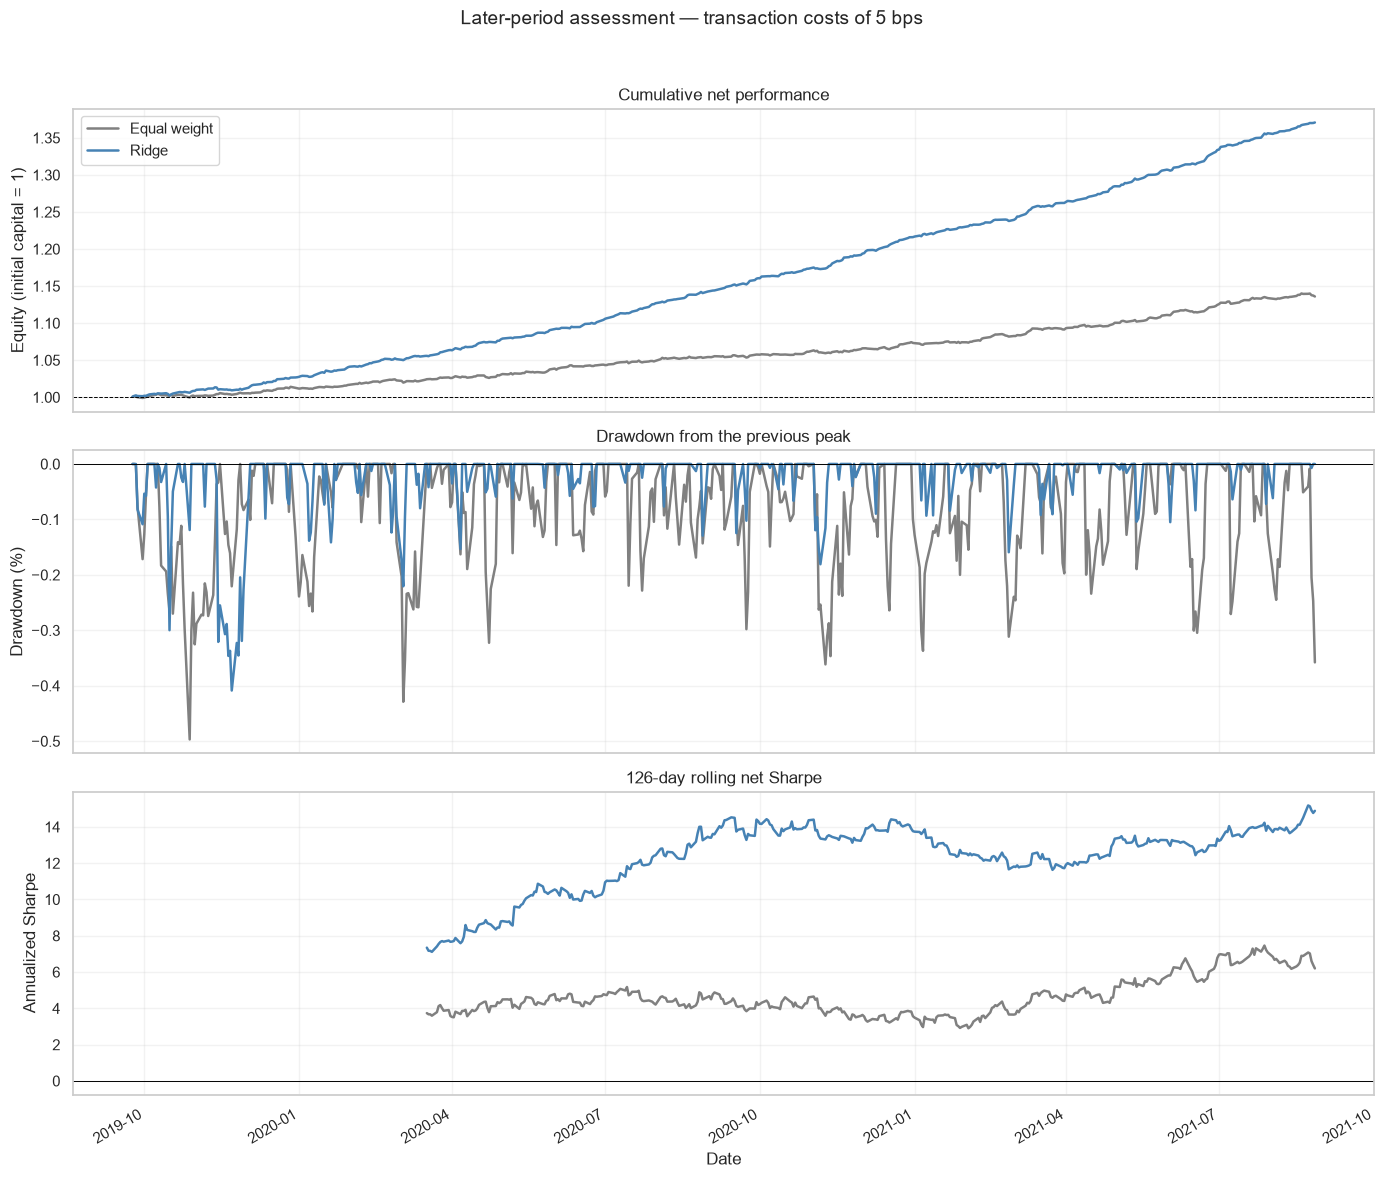

In [75]:
# 6.5 — Assessment performance charts

plot_cost = ASSESSMENT_CONFIG["primary_cost_bps"]
strategies = ["Equal weight", "Ridge"]

assessment_net_returns = pd.DataFrame({
    strategy: assessment_backtests[
        (strategy, plot_cost)
    ]["Net return"]
    for strategy in strategies
})

# Compound daily net returns, starting with capital of 1.
assessment_equity = (1 + assessment_net_returns).cumprod()

# Include initial capital when determining the running peak.
assessment_running_peak = (
    assessment_equity.cummax().clip(lower=1.0)
)

assessment_drawdown = (
    assessment_equity.div(assessment_running_peak) - 1
) * 100

# Rolling Sharpe over 126 observations.
ROLLING_WINDOW = 126

rolling_returns = assessment_net_returns.rolling(
    window=ROLLING_WINDOW,
    min_periods=ROLLING_WINDOW,
)

rolling_std = rolling_returns.std(ddof=1)

assessment_rolling_sharpe = (
    np.sqrt(ANNUALIZATION)
    * rolling_returns.mean()
    / rolling_std.where(rolling_std > 0)
)

colors = {
    "Equal weight": "gray",
    "Ridge": "steelblue",
}

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 12),
    sharex=True,
)

panels = [
    (
        assessment_equity,
        "Cumulative net performance",
        "Equity (initial capital = 1)",
    ),
    (
        assessment_drawdown,
        "Drawdown from the previous peak",
        "Drawdown (%)",
    ),
    (
        assessment_rolling_sharpe,
        "126-day rolling net Sharpe",
        "Annualized Sharpe",
    ),
]

for ax, (table, title, ylabel) in zip(axes, panels):
    for strategy in strategies:
        ax.plot(
            table.index.to_pydatetime(),
            table[strategy].to_numpy(),
            label=strategy,
            color=colors[strategy],
            linewidth=1.8,
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

axes[0].axhline(1, color="black", linewidth=0.7, linestyle="--")
axes[0].legend()

axes[1].axhline(0, color="black", linewidth=0.7)
axes[2].axhline(0, color="black", linewidth=0.7)
axes[2].set_xlabel("Date")

fig.suptitle(
    f"Later-period assessment — transaction costs of {plot_cost} bps",
    fontsize=14,
)

fig.autofmt_xdate()
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Monthly rolling Ridge with λ = 0.1 and one-day smoothing outperformed the equally smoothed baseline during the assessment period. At 5 bps per unit traded, Ridge achieved a Sharpe ratio of 11.68 versus 4.60, with cumulative returns of 37.07% versus 13.59%, lower maximum drawdown and less daily trading. Both portfolios maintained dollar neutrality and estimated beta neutrality. These results support the selected approach, although the previously examined assessment period does not constitute independent validation.

In [76]:
%pip install cvxpy

Note: you may need to restart the kernel to use updated packages.


# 7 — Portfolio optimization

### 7.1 — Portfolio optimization: configuration and research inputs

In [77]:
# 7.1 — Portfolio optimization: configuration and research inputs

import cvxpy as cp
from sklearn.covariance import LedoitWolf

OPTIMIZATION_CONFIG = {
    "ridge_model": "Ridge lambda=0.1",
    "covariance_window_dates": 252,
    "return_lag_dates": 2,
    "covariance_update_frequency": "monthly",
    "rebalance_frequency": "daily",
    "net_exposure": 0.0,
    "estimated_beta": 0.0,
    "gross_limit": 1.0,
    "max_abs_stock_weight": 0.02,
    "cost_bps": 5,
    # Exploratory settings evaluated on the research period only.
    # This parameter is separate from the Ridge penalty.
    "risk_aversion_grid": [100.0, 300.0, 1000.0],
    "initial_positions": "cash",
}

opt_dates = pd.DatetimeIndex(
    monthly_evaluation_dates
).sort_values()

opt_assets = monthly_assets.sort_values()

# Reuse existing chronological Ridge predictions.
# Preserve their daily return units for the optimizer.
opt_expected_returns = (
    ridge_monthly_predictions[
        OPTIMIZATION_CONFIG["ridge_model"]
    ]
    .unstack("asset")
    .reindex(index=opt_dates, columns=opt_assets)
)

# Existing daily historical beta estimates.
opt_betas = monthly_betas.reindex(
    index=opt_dates,
    columns=opt_assets,
).copy()

# Existing selected Ridge portfolio for comparison.
opt_reference_weights = monthly_smoothed_weights[
    (OPTIMIZATION_CONFIG["ridge_model"], "1-day")
].reindex(
    index=opt_dates,
    columns=opt_assets,
).copy()

# Include earlier research history for covariance estimation.
# The next subsection will select eligible past rows at each update.
opt_return_history = (
    df_asset.sort_index()
    .loc[:opt_dates.max(), opt_assets]
    .copy()
)

# Forward outcomes used later for backtesting.
opt_asset_returns = opt_return_history.reindex(opt_dates)

# Keep optimizer development inside the research period.
assert opt_dates.is_unique
assert opt_assets.is_unique
assert opt_dates.isin(research_dates).all()
assert not opt_dates.isin(validation_dates).any()

for name, table in {
    "Expected returns": opt_expected_returns,
    "Estimated betas": opt_betas,
    "Reference weights": opt_reference_weights,
    "Asset returns": opt_asset_returns,
}.items():
    assert table.index.equals(opt_dates), name
    assert table.columns.equals(opt_assets), name
    assert np.isfinite(table.to_numpy()).all(), name

assert opt_return_history.index.is_unique
assert np.isfinite(opt_return_history.to_numpy()).all()

display(
    pd.Series(
        OPTIMIZATION_CONFIG,
        name="Setting",
    ).to_frame()
)

print(
    f"Research period: {opt_dates.min().date()} "
    f"to {opt_dates.max().date()}"
)
print(f"Dates: {len(opt_dates):,} | Stocks: {len(opt_assets):,}")
print("Available optimization solvers:", cp.installed_solvers())

,Setting
ridge_model,Ridge lambda=0.1
covariance_window_dates,252
return_lag_dates,2
covariance_update_frequency,monthly
rebalance_frequency,daily
net_exposure,0.0
estimated_beta,0.0
gross_limit,1.0
max_abs_stock_weight,0.02
cost_bps,5


Research period: 2013-12-09 to 2019-09-20
Dates: 1,510 | Stocks: 500
Available optimization solvers: ['CLARABEL', 'SCS', 'SCIPY', 'HIGHS', 'OSQP']


### 7.2 — Estimate the historical covariance matrices

In [78]:
cov_window = OPTIMIZATION_CONFIG["covariance_window_dates"]
return_lag = OPTIMIZATION_CONFIG["return_lag_dates"]

assert cov_window > 1
assert return_lag >= 1
assert opt_return_history.index.is_monotonic_increasing
assert opt_return_history.index.is_unique
assert opt_return_history.columns.equals(opt_assets)

# One covariance matrix per monthly update.
opt_covariances = {}

# Identify which estimate applies to each allocation date.
opt_covariance_date = pd.Series(
    pd.NaT,
    index=opt_dates,
    dtype="datetime64[ns]",
    name="Covariance update",
)

opt_covariance_rows = []

monthly_groups = pd.Series(
    opt_dates,
    index=opt_dates,
).groupby(opt_dates.to_period("M"))

for block_number, (_, date_group) in enumerate(
    monthly_groups,
    start=1,
):
    block_dates = pd.DatetimeIndex(date_group.to_numpy())
    update_date = block_dates[0]

    update_position = opt_return_history.index.get_loc(
        update_date
    )

    # With lag=2, the last included return is at position t-2.
    # iloc excludes its right endpoint, hence the +1.
    history_stop = update_position - return_lag + 1
    history_start = history_stop - cov_window

    if history_start < 0:
        raise ValueError(
            f"Insufficient covariance history at {update_date.date()}."
        )

    history = opt_return_history.iloc[
        history_start:history_stop
    ]

    assert len(history) == cov_window
    assert history.index[-1] == opt_return_history.index[
        update_position - return_lag
    ]
    assert history.index[-1] < update_date
    assert np.isfinite(history.to_numpy()).all()

    # No inverse covariance is needed.
    estimator = LedoitWolf(store_precision=False)
    estimator.fit(history.to_numpy(dtype=float))

    covariance = estimator.covariance_

    # Remove numerical asymmetry and verify positive definiteness.
    covariance = 0.5 * (covariance + covariance.T)

    assert np.isfinite(covariance).all()
    np.linalg.cholesky(covariance)

    opt_covariances[update_date] = covariance
    opt_covariance_date.loc[block_dates] = update_date

    opt_covariance_rows.append({
        "Update date": update_date,
        "History start": history.index[0],
        "History end": history.index[-1],
        "Used through": block_dates[-1],
        "Observations": len(history),
        "Shrinkage": float(estimator.shrinkage_),
    })

    if block_number == 1 or block_number % 12 == 0:
        print(f"Computed {block_number} covariance estimates")

opt_covariance_summary = (
    pd.DataFrame(opt_covariance_rows)
    .set_index("Update date")
)

# Every allocation date must have an available covariance estimate.
assert opt_covariance_date.notna().all()

assert all(
    update_date <= allocation_date
    for allocation_date, update_date
    in opt_covariance_date.items()
)

print(f"\nMonthly covariance estimates: {len(opt_covariances)}")
print(f"Matrix dimensions: {len(opt_assets)} × {len(opt_assets)}")

display(opt_covariance_summary.head())
display(opt_covariance_summary.tail())

Computed 1 covariance estimates
Computed 12 covariance estimates
Computed 24 covariance estimates
Computed 36 covariance estimates
Computed 48 covariance estimates
Computed 60 covariance estimates

Monthly covariance estimates: 70
Matrix dimensions: 500 × 500


,History start,History end,Used through,Observations,Shrinkage
Update date,,,,,
2013-12-09,2012-12-19,2013-12-05,2013-12-31,252,0.324924
2014-01-01,2013-01-11,2013-12-30,2014-01-31,252,0.299936
2014-02-03,2013-02-13,2014-01-30,2014-02-28,252,0.289345
2014-03-03,2013-03-13,2014-02-27,2014-03-31,252,0.312468
2014-04-01,2013-04-11,2014-03-28,2014-04-30,252,0.316391


,History start,History end,Used through,Observations,Shrinkage
Update date,,,,,
2019-05-01,2018-05-11,2019-04-29,2019-05-31,252,0.325666
2019-06-03,2018-06-13,2019-05-30,2019-06-28,252,0.302239
2019-07-01,2018-07-11,2019-06-27,2019-07-31,252,0.291395
2019-08-01,2018-08-13,2019-07-30,2019-08-30,252,0.311374
2019-09-02,2018-09-12,2019-08-29,2019-09-20,252,0.317131


## 7.3 — Define the portfolio optimizer

In [79]:
# 7.3 — Define the constrained portfolio optimizer

def build_ridge_optimizer(covariance, risk_aversion):
    config = OPTIMIZATION_CONFIG.copy()
    covariance = np.asarray(covariance, dtype=float)
    n_assets = len(opt_assets)

    if covariance.shape != (n_assets, n_assets):
        raise ValueError("Covariance dimensions do not match the assets.")
    if not np.isfinite(covariance).all():
        raise ValueError("Covariance contains invalid values.")
    if not np.isfinite(risk_aversion) or risk_aversion <= 0:
        raise ValueError("Risk aversion must be positive.")

    covariance = 0.5 * (covariance + covariance.T)
    np.linalg.cholesky(covariance)

    # Portfolio weights to choose.
    w = cp.Variable(n_assets)

    # Inputs updated each day.
    mu = cp.Parameter(n_assets)
    beta = cp.Parameter(n_assets)
    pretrade = cp.Parameter(n_assets)

    expected_return = mu @ w
    variance = cp.quad_form(w, cp.psd_wrap(covariance))

    trading_cost = (
        config["cost_bps"] / 10_000
        * cp.norm1(w - pretrade)
    )

    # Scaling the entire objective improves numerical conditioning
    # without changing the optimal allocation.
    objective = cp.Maximize(
        10_000 * (
            expected_return
            - 0.5 * risk_aversion * variance
            - trading_cost
        )
    )

    constraints = [
        cp.sum(w) == config["net_exposure"],
        beta @ w == config["estimated_beta"],
        cp.norm1(w) <= config["gross_limit"],
        cp.abs(w) <= config["max_abs_stock_weight"],
    ]

    problem = cp.Problem(objective, constraints)
    assert problem.is_dpp()

    return {
        "problem": problem,
        "weights": w,
        "mu": mu,
        "beta": beta,
        "pretrade": pretrade,
    }


def solve_ridge_optimizer(optimizer, mu, betas, pretrade):
    for key, values in [
        ("mu", mu),
        ("beta", betas),
        ("pretrade", pretrade),
    ]:
        values = np.asarray(values, dtype=float)
        parameter = optimizer[key]

        if values.shape != parameter.shape:
            raise ValueError(f"Wrong shape for {key}.")
        if not np.isfinite(values).all():
            raise ValueError(f"Invalid values in {key}.")

        parameter.value = values

    problem = optimizer["problem"]

    problem.solve(
        solver=cp.CLARABEL,
        warm_start=True,
        enforce_dpp=True,
        max_iter=200,
        tol_gap_abs=1e-9,
        tol_gap_rel=1e-9,
        tol_feas=1e-9,
        verbose=False,
    )

    if problem.status != cp.OPTIMAL:
        raise RuntimeError(
            f"Optimization failed: {problem.status}"
        )

    weights = np.asarray(
        optimizer["weights"].value,
        dtype=float,
    ).copy()

    if not np.isfinite(weights).all():
        raise RuntimeError("Optimizer returned invalid weights.")

    # Check the actual returned allocation against every constraint.
    max_violation = max(
        float(np.max(constraint.violation()))
        for constraint in problem.constraints
    )

    if max_violation > 1e-7:
        raise RuntimeError(
            f"Constraint violation: {max_violation:.2e}"
        )

    return weights

In [80]:
# Check the first research allocation.

demo_date = opt_dates[0]
demo_gamma = 300.0

demo_covariance = opt_covariances[
    opt_covariance_date.loc[demo_date]
]

demo_mu = opt_expected_returns.loc[demo_date].to_numpy()
demo_betas = opt_betas.loc[demo_date].to_numpy()
demo_pretrade = np.zeros(len(opt_assets))

demo_optimizer = build_ridge_optimizer(
    covariance=demo_covariance,
    risk_aversion=demo_gamma,
)

demo_weights = solve_ridge_optimizer(
    optimizer=demo_optimizer,
    mu=demo_mu,
    betas=demo_betas,
    pretrade=demo_pretrade,
)

demo_variance = float(
    demo_weights @ demo_covariance @ demo_weights
)

demo_traded_weight = np.abs(
    demo_weights - demo_pretrade
).sum()

demo_diagnostics = pd.Series({
    "Net dollar exposure": demo_weights.sum(),
    "Estimated beta": demo_betas @ demo_weights,
    "Gross exposure": np.abs(demo_weights).sum(),
    "Largest absolute stock weight (%)": (
        np.abs(demo_weights).max() * 100
    ),
    "Predicted gross daily return (bps)": (
        demo_mu @ demo_weights * 10_000
    ),
    "Estimated annualized volatility (%)": (
        np.sqrt(ANNUALIZATION * demo_variance) * 100
    ),
    "Initial trading cost (bps of equity)": (
        OPTIMIZATION_CONFIG["cost_bps"] * demo_traded_weight
    ),
})

print(f"Date: {demo_date.date()} | Risk aversion: {demo_gamma:g}")
print("Solver status:", demo_optimizer["problem"].status)

display(demo_diagnostics.round(6).to_frame("First allocation"))

Date: 2013-12-09 | Risk aversion: 300
Solver status: optimal


,First allocation
Net dollar exposure,0.000000
Estimated beta,-0.000000
Gross exposure,1.000000
Largest absolute stock weight (%),2.000000
Predicted gross daily return (bps),12.064878
Estimated annualized volatility (%),1.976894
Initial trading cost (bps of equity),5.000000


### 7.4 — Run the chronological optimization backtest

In [81]:
# 7.4 — Chronological backtest of optimized portfolios

from time import perf_counter
from threadpoolctl import threadpool_limits


def run_optimized_backtest(risk_aversion):
    n_dates, n_assets = opt_expected_returns.shape

    mu_values = opt_expected_returns.to_numpy(dtype=float)
    beta_values = opt_betas.to_numpy(dtype=float)
    return_values = opt_asset_returns.to_numpy(dtype=float)

    pretrade = np.zeros(n_assets)
    target_history = np.empty((n_dates, n_assets))
    records = []

    active_covariance_date = None
    started = perf_counter()
    cost_rate = OPTIMIZATION_CONFIG["cost_bps"] / 10_000

    for i, date in enumerate(opt_dates):
        covariance_date = opt_covariance_date.loc[date]

        # Rebuild when the monthly covariance estimate changes.
        # Existing holdings remain in pretrade.
        if covariance_date != active_covariance_date:
            covariance = opt_covariances[covariance_date]

            optimizer = build_ridge_optimizer(
                covariance=covariance,
                risk_aversion=risk_aversion,
            )

            active_covariance_date = covariance_date

        try:
            target = solve_ridge_optimizer(
                optimizer=optimizer,
                mu=mu_values[i],
                betas=beta_values[i],
                pretrade=pretrade,
            )
        except (
            cp.error.SolverError,
            RuntimeError,
            ValueError,
        ) as error:
            raise RuntimeError(
                f"gamma={risk_aversion:g}, "
                f"date={date.date()}: {error}"
            ) from error

        # Apply today's outcomes after choosing today's positions.
        stock_returns = return_values[i]

        traded_weight = float(
            np.abs(target - pretrade).sum()
        )
        trading_cost = cost_rate * traded_weight

        gross_return = float(target @ stock_returns)
        net_return = gross_return - trading_cost

        if not np.isfinite(net_return) or 1 + net_return <= 0:
            raise RuntimeError(
                f"Invalid portfolio return at {date.date()}."
            )

        target_history[i] = target.copy()

        records.append({
            "Gross return": gross_return,
            "Net return": net_return,
            "Traded weight": traded_weight,
            "Trading cost": trading_cost,
            "Target gross exposure": float(
                np.abs(target).sum()
            ),
            "Target net exposure": float(target.sum()),
            "Target estimated beta": float(
                target @ beta_values[i]
            ),
            "Largest absolute target weight": float(
                np.abs(target).max()
            ),
            "Predicted daily variance": float(
                target @ covariance @ target
            ),
        })

        # Holdings entering the next date, relative to ending capital.
        pretrade = (
            target * (1 + stock_returns) / (1 + net_return)
        )

        if (
            i == 0
            or (i + 1) % 126 == 0
            or i + 1 == n_dates
        ):
            elapsed_minutes = (perf_counter() - started) / 60

            print(
                f"gamma={risk_aversion:g}: "
                f"{i + 1}/{n_dates} dates "
                f"({elapsed_minutes:.1f} minutes)",
                flush=True,
            )

    targets = pd.DataFrame(
        target_history,
        index=opt_dates,
        columns=opt_assets,
    )

    backtest = pd.DataFrame(
        records,
        index=opt_dates,
    )

    return targets, backtest

In [82]:
opt_weights = {}
opt_backtests = {}

# Limit parallel overhead during repeated numerical calculations.
with threadpool_limits(limits=1):
    for gamma in OPTIMIZATION_CONFIG["risk_aversion_grid"]:
        strategy = f"Ridge optimized gamma={gamma:g}"

        targets, backtest = run_optimized_backtest(gamma)

        opt_weights[strategy] = targets
        opt_backtests[strategy] = backtest

print("\nAll optimization backtests completed.")

gamma=100: 1/1510 dates (0.0 minutes)
gamma=100: 126/1510 dates (0.6 minutes)
gamma=100: 252/1510 dates (1.2 minutes)
gamma=100: 378/1510 dates (1.8 minutes)
gamma=100: 504/1510 dates (2.4 minutes)
gamma=100: 630/1510 dates (3.1 minutes)
gamma=100: 756/1510 dates (3.7 minutes)
gamma=100: 882/1510 dates (4.2 minutes)
gamma=100: 1008/1510 dates (4.8 minutes)
gamma=100: 1134/1510 dates (5.4 minutes)
gamma=100: 1260/1510 dates (6.0 minutes)
gamma=100: 1386/1510 dates (6.6 minutes)
gamma=100: 1510/1510 dates (7.2 minutes)
gamma=300: 1/1510 dates (0.0 minutes)
gamma=300: 126/1510 dates (0.5 minutes)
gamma=300: 252/1510 dates (1.1 minutes)
gamma=300: 378/1510 dates (1.7 minutes)
gamma=300: 504/1510 dates (2.2 minutes)
gamma=300: 630/1510 dates (2.8 minutes)
gamma=300: 756/1510 dates (3.4 minutes)
gamma=300: 882/1510 dates (3.9 minutes)
gamma=300: 1008/1510 dates (4.4 minutes)
gamma=300: 1134/1510 dates (5.0 minutes)
gamma=300: 1260/1510 dates (5.6 minutes)
gamma=300: 1386/1510 dates (6.1 minu

In [83]:
opt_execution_rows = []

for strategy, backtest in opt_backtests.items():
    opt_execution_rows.append({
        "Strategy": strategy,
        "Dates": len(backtest),
        "Average gross exposure": (
            backtest["Target gross exposure"].mean()
        ),
        "Maximum absolute net exposure": (
            backtest["Target net exposure"].abs().max()
        ),
        "Maximum absolute estimated beta": (
            backtest["Target estimated beta"].abs().max()
        ),
        "Largest absolute stock weight (%)": (
            backtest["Largest absolute target weight"].max() * 100
        ),
        "Average daily traded weight (%)": (
            backtest["Traded weight"].mean() * 100
        ),
    })

opt_execution_summary = (
    pd.DataFrame(opt_execution_rows)
    .set_index("Strategy")
)

display(opt_execution_summary.round(6))

,Dates,Average gross exposure,Maximum absolute net exposure,Maximum absolute estimated beta,Largest absolute stock weight (%),Average daily traded weight (%)
Strategy,,,,,,
Ridge optimized gamma=100,1510,1.000000,0.0,0.0,2.000000,11.953783
Ridge optimized gamma=300,1510,1.000000,0.0,0.0,2.000000,10.215432
Ridge optimized gamma=1000,1510,0.999709,0.0,0.0,1.937347,7.664610


### 7.5 — Compare optimized portfolios with the baselines.

In [84]:
# 7.5 — Research-period performance comparison

comparison_cost = OPTIMIZATION_CONFIG["cost_bps"]

optimized_names = [
    f"Ridge optimized gamma={gamma:g}"
    for gamma in OPTIMIZATION_CONFIG["risk_aversion_grid"]
]

if (
    "opt_backtests" not in globals()
    or "opt_weights" not in globals()
    or not all(
        name in opt_backtests and name in opt_weights
        for name in optimized_names
    )
):
    raise RuntimeError(
        "Complete Section 7.4 for all three risk settings first."
    )

# Reuse the existing research-period benchmark backtests.
opt_comparison_backtests = {
    "Equal weight | 1-day smoothing": monthly_smoothing_backtests[
        ("Equal weight", "1-day", comparison_cost)
    ],
    "Ridge | 1-day smoothing": monthly_smoothing_backtests[
        (
            OPTIMIZATION_CONFIG["ridge_model"],
            "1-day",
            comparison_cost,
        )
    ],
}

opt_comparison_weights = {
    "Equal weight | 1-day smoothing": monthly_smoothed_weights[
        ("Equal weight", "1-day")
    ],
    "Ridge | 1-day smoothing": opt_reference_weights,
}

for name in optimized_names:
    opt_comparison_backtests[name] = opt_backtests[name]
    opt_comparison_weights[name] = opt_weights[name]

opt_comparison_rows = []

for strategy, backtest in opt_comparison_backtests.items():
    target_weights = opt_comparison_weights[strategy]

    # Require complete results on exactly the same dates and assets.
    assert backtest.index.equals(opt_dates), strategy
    assert target_weights.index.equals(opt_dates), strategy
    assert target_weights.columns.equals(opt_assets), strategy
    assert np.isfinite(target_weights.to_numpy()).all(), strategy

    required_columns = [
        "Net return",
        "Traded weight",
        "Trading cost",
    ]
    assert np.isfinite(
        backtest[required_columns].to_numpy()
    ).all(), strategy

    # Confirm that every strategy uses the same cost assumption.
    np.testing.assert_allclose(
        backtest["Trading cost"].to_numpy(),
        (
            comparison_cost / 10_000
            * backtest["Traded weight"].to_numpy()
        ),
        atol=1e-12,
        rtol=1e-9,
        err_msg=strategy,
    )

    net_returns = backtest["Net return"]

    metrics = summarize_portfolio(net_returns).to_dict()

    metrics.update({
        "Strategy": strategy,
        "Annualized volatility (%)": (
            net_returns.std(ddof=1)
            * np.sqrt(ANNUALIZATION)
            * 100
        ),
        "Average target gross exposure": (
            target_weights.abs().sum(axis=1).mean()
        ),
        "Average daily traded weight (%)": (
            backtest["Traded weight"].mean() * 100
        ),
        "Largest absolute target weight (%)": (
            target_weights.abs().to_numpy().max() * 100
        ),
    })

    opt_comparison_rows.append(metrics)

opt_comparison_performance = (
    pd.DataFrame(opt_comparison_rows)
    .set_index("Strategy")
)

performance_columns = [
    "Annualized Sharpe",
    "Annualized Sortino",
    "Total return (%)",
    "Maximum drawdown (%)",
    "Annualized volatility (%)",
]

exposure_columns = [
    "Average target gross exposure",
    "Average daily traded weight (%)",
    "Largest absolute target weight (%)",
]

print(
    f"Research comparison: {opt_dates.min().date()} "
    f"to {opt_dates.max().date()} | Cost: {comparison_cost} bps"
)

display(
    opt_comparison_performance[performance_columns].round(4)
)

print("Exposure, trading activity and concentration")

display(
    opt_comparison_performance[exposure_columns].round(4)
)

Research comparison: 2013-12-09 to 2019-09-20 | Cost: 5 bps


,Annualized Sharpe,Annualized Sortino,Total return (%),Maximum drawdown (%),Annualized volatility (%)
Strategy,,,,,
Equal weight | 1-day smoothing,3.2337,5.4920,31.8515,1.4177,1.4303
Ridge | 1-day smoothing,11.5137,30.9097,160.6095,0.5100,1.3897
Ridge optimized gamma=100,7.0201,14.6524,227.6055,1.8836,2.8278
Ridge optimized gamma=300,7.6712,16.6500,175.4110,1.1749,2.2079
Ridge optimized gamma=1000,8.0252,17.9754,110.9428,0.8775,1.5541


Exposure, trading activity and concentration


,Average target gross exposure,Average daily traded weight (%),Largest absolute target weight (%)
Strategy,,,
Equal weight | 1-day smoothing,1.0000,27.7270,1.1784
Ridge | 1-day smoothing,1.0000,22.7675,1.1965
Ridge optimized gamma=100,1.0000,11.9538,2.0000
Ridge optimized gamma=300,1.0000,10.2154,2.0000
Ridge optimized gamma=1000,0.9997,7.6646,1.9373


Portfolio optimization substantially reduced trading activity but did not improve risk-adjusted performance relative to the smoothed Ridge benchmark. Lower risk-aversion settings generated higher cumulative returns alongside greater volatility and drawdowns. Among the optimized candidates, γ=1000 achieved the highest Sharpe, but remained below the benchmark. We therefore retain monthly rolling Ridge with λ=0.1 and one-day smoothing as the preferred approach based on these research-period results.

# Test Aggregator

In [85]:
from aggregator import RidgeAlphaAggregator

model = RidgeAlphaAggregator()
weights = model.walk_forward(
    df_alphas,
    df_asset,
    start_date=validation_dates[0],
    end_date=validation_dates[-1],
)

In [86]:
# Verify that aggregator.py reproduces the notebook.

aggregator_weights = weights.copy()
notebook_weights = assessment_weights["Ridge"]

# 1. Compare every portfolio weight.
assert aggregator_weights.index.equals(notebook_weights.index)
assert aggregator_weights.columns.equals(notebook_weights.columns)

np.testing.assert_allclose(
    aggregator_weights.to_numpy(),
    notebook_weights.to_numpy(),
    atol=1e-10,
    rtol=0,
)

max_weight_difference = np.abs(
    aggregator_weights.to_numpy()
    - notebook_weights.to_numpy()
).max()

print(
    "PASS — portfolio weights match. "
    f"Maximum difference: {max_weight_difference:.2e}"
)

# 2. Apply the same backtest and trading costs.
check_cost_bps = 5

check_asset_returns = df_asset.reindex(
    index=aggregator_weights.index,
    columns=aggregator_weights.columns,
)

assert np.isfinite(check_asset_returns.to_numpy()).all()

aggregator_backtest = backtest_beta_portfolio(
    target_weights=aggregator_weights,
    asset_returns=check_asset_returns,
    cost_bps=check_cost_bps,
)

notebook_backtest = assessment_backtests[
    ("Ridge", check_cost_bps)
]

assert aggregator_backtest.index.equals(notebook_backtest.index)

check_columns = [
    "Gross return",
    "Net return",
    "Traded weight",
    "Trading cost",
]

np.testing.assert_allclose(
    aggregator_backtest[check_columns].to_numpy(),
    notebook_backtest[check_columns].to_numpy(),
    atol=1e-10,
    rtol=0,
)

print("PASS — daily returns, trading activity and costs match.")

# 3. Display performance side by side.
comparison_metrics = {}

for label, backtest in {
    "Notebook": notebook_backtest,
    "aggregator.py": aggregator_backtest,
}.items():
    metrics = summarize_portfolio(backtest["Net return"])

    metrics["Average daily traded weight (%)"] = (
        backtest["Traded weight"].mean() * 100
    )

    comparison_metrics[label] = metrics

aggregator_comparison = pd.DataFrame(comparison_metrics)

aggregator_comparison["Absolute difference"] = (
    aggregator_comparison["aggregator.py"]
    - aggregator_comparison["Notebook"]
).abs()

display(aggregator_comparison.round(6))

PASS — portfolio weights match. Maximum difference: 1.39e-17
PASS — daily returns, trading activity and costs match.


,Notebook,aggregator.py,Absolute difference
Annualized Sharpe,11.680302,11.680302,0.0
Annualized Sortino,31.288174,31.288174,0.0
Total return (%),37.073245,37.073245,0.0
Maximum drawdown (%),0.408642,0.408642,0.0
Average daily traded weight (%),22.232856,22.232856,0.0
